In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation")  # <<< updated path here to refer to the implementation of OT-Impute and other imputation methods
import utils
import Inject_Missing_Values
import Updated_OT
import imputers
import imputers_fullyActive

In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from Inject_Missing_Values import *
from imputers import OTimputer #original OT imputer
from Updated_OT import OTimputerDropOutNoise #dropout noise imputer
from imputers_fullyActive import OTimputerFullyActive # fully activeOT

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)

### Adult Data

Loading the data

In [5]:
data = fetch_openml(name="adult", version=2, as_frame=True)
X_full = data.data.copy()

In [6]:
# Convert categorical to numerical codes
for col in X_full.select_dtypes(include=['category', 'object']).columns:
    X_full[col] = X_full[col].astype('category').cat.codes

In [7]:
scaler = MinMaxScaler() #data [0,1]
X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [8]:
GroundTruth = X_full.copy()
X = X_full.copy()

Dependecies for MAR & MNAR

In [9]:
mean_age = GroundTruth["age"].mean()
mean_workclass = GroundTruth["workclass"].mean()
median_fnlwgt = GroundTruth["fnlwgt"].median()
mean_education = GroundTruth["education"].mean()
median_educationnum = GroundTruth["education-num"].median()
mean_maritalStatus = GroundTruth["marital-status"].mean()
mean_occupation = GroundTruth["occupation"].mean()
median_relationship = GroundTruth["relationship"].median()
mean_race = GroundTruth["race"].mean()
mean_sex = GroundTruth["sex"].mean()
median_capitalgain = GroundTruth["capital-gain"].median()
mean_capitalloss = GroundTruth["capital-loss"].mean()
median_hoursperweek = GroundTruth["hours-per-week"].median()
mean_nativecountry = GroundTruth["native-country"].mean()




dependencies_mar = {
    "age": {
        "influencers": ["workclass"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["workclass"] >= mean_workclass else 0.1
    },
    "workclass": {
        "influencers": ["capital-gain"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["capital-gain"] < median_capitalgain else 0.1
    },
    "fnlwgt": {
        "influencers": ["education-num"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["education-num"] <= median_educationnum else 0.1
    },
    "education": {
        "influencers": ["sex"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["sex"] == 0 else 0.1
    },
    "education-num": {
        "influencers": ["sex"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["sex"] == 0 else 0.1
    },
    "marital-status": {
        "influencers": ["relationship"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["relationship"] <= median_relationship else 0.1
    },
    "occupation": {
        "influencers": ["workclass"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["workclass"] < mean_workclass else 0.1
    },
    "relationship": {
        "influencers": ["marital-status"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["marital-status"] < mean_maritalStatus else 0.1
    },
    "race": {
        "influencers": ["workclass"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["workclass"] >= mean_workclass else 0.1
    },
    "sex": {
        "influencers": ["workclass"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["workclass"] <= mean_workclass else 0.1
    },
    "capital-gain": {
        "influencers": ["sex"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["sex"] == 1 else 0.1
    },
    "capital-loss": {
        "influencers": ["capital-gain"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["capital-gain"] < median_capitalgain else 0.1
    },
    "hours-per-week": {
        "influencers": ["age"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] <= mean_age else 0.1
    },
    "native-country": {
        "influencers": ["race"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["race"] <= mean_race else 0.1
    },
    
}

In [11]:
mean_age = GroundTruth["age"].mean()
mean_workclass = GroundTruth["workclass"].mean()
median_fnlwgt = GroundTruth["fnlwgt"].median()
mean_education = GroundTruth["education"].mean()
median_educationnum = GroundTruth["education-num"].median()
mean_maritalStatus = GroundTruth["marital-status"].mean()
mean_occupation = GroundTruth["occupation"].mean()
median_relationship = GroundTruth["relationship"].median()
mean_race = GroundTruth["race"].mean()
mean_sex = GroundTruth["sex"].mean()
median_capitalgain = GroundTruth["capital-gain"].median()
mean_capitalloss = GroundTruth["capital-loss"].mean()
median_hoursperweek = GroundTruth["hours-per-week"].median()
mean_nativecountry = GroundTruth["native-country"].mean()

dependencies_mnar = {
    "age": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] > mean_age else 0.1
    },
    "workclass": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["workclass"] < mean_workclass else 0.1
    },
    "fnlwgt": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["fnlwgt"] >= median_fnlwgt else 0.1
    },
    "education": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["education"] > mean_education else 0.1
    },
    "education-num": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["education-num"] == median_educationnum else 0.1
    },
    "marital-status": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["marital-status"] <= mean_maritalStatus else 0.1
    },
    "occupation": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["occupation"] < mean_occupation else 0.1
    },
    "relationship": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["relationship"] <= median_relationship else 0.1
    },
    "race": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["race"] < mean_race else 0.1
    },
    "sex": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["sex"] == 0 else 0.1
    },
    "capital-gain": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["capital-gain"] > median_capitalgain else 0.1
    },
    "capital-loss": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["capital-loss"] < mean_capitalloss else 0.1
    },
    "hours-per-week": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["hours-per-week"] <= median_hoursperweek else 0.1
    },
    "native-country": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["native-country"] <= mean_nativecountry else 0.1
    }
}

## Running OT-Impute, OT-Rand & Batch-Impute

## MCAR

In [ ]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing
budgets = [0.1, 0.2, 0.3]  # Query 10%, 25%, 50% of missing cells

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}


for missing_rate in missing_rates:
    generator_mcar = Inject_Missing_Values() #missing value generating
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()

    

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mcar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mcar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mcar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mcar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mcar[metric]:
        for method in results_mcar[metric][budget]:
            values = results_mcar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mcar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mcar = df_results_mcar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mcar.columns.name = None
df_results_mcar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mcar.columns]
df_results_mcar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Adult_results_mcar_metrics.csv", index=False)
    

Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%



Plotting results...


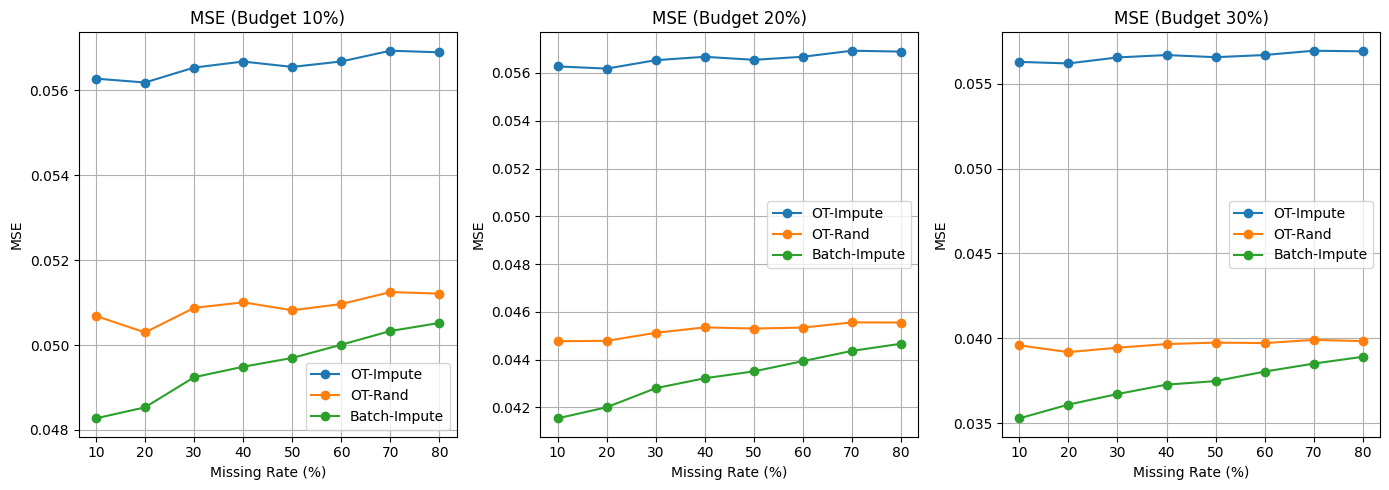

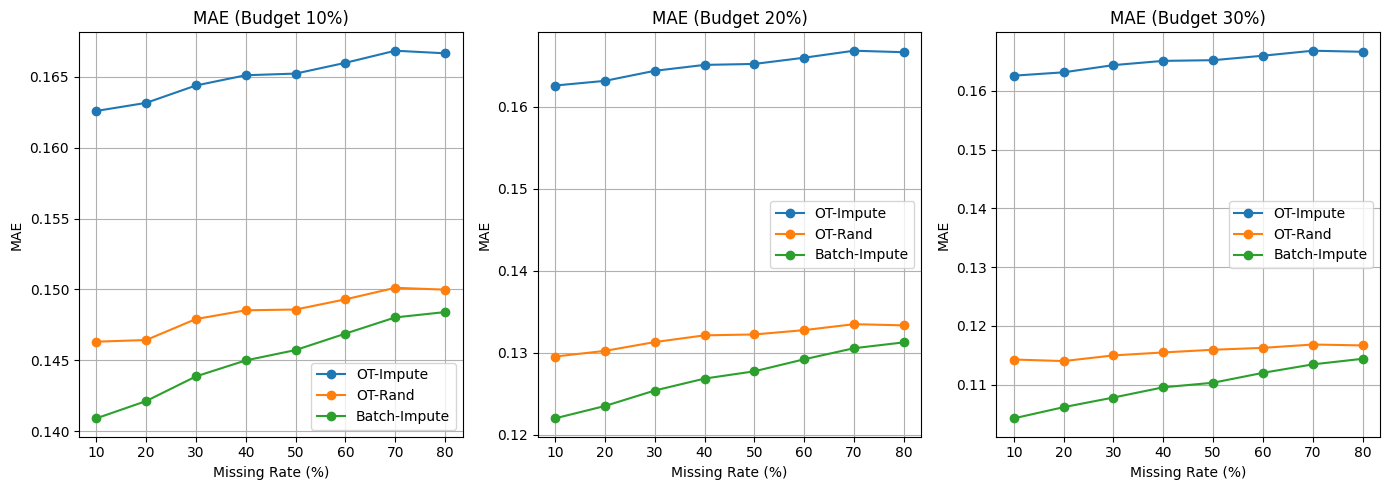

In [10]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

## MAR

In [ ]:
results_mar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    total_missing_percentage_mar = miss_mar.isnull().sum().sum() / miss_mar.size * 100
    print(f"Total Missing Percentage MAR: {total_missing_percentage_mar:.2f}%")

    missing_percentage = (miss_mar.isnull().sum() / len(miss_mar)) * 100
    print(missing_percentage)

    missing_mask = miss_mar.isna()

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mar[metric]:
        for method in results_mar[metric][budget]:
            values = results_mar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mar = df_results_mar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mar.columns.name = None
df_results_mar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mar.columns]
df_results_mar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Adult_results_mar_metrics.csv", index=False)
    

Total Missing Percentage MAR: 10.00%
age               16.051759
workclass          3.789771
fnlwgt            13.590762
education          8.662626
education-num      8.816183
marital-status    13.226322
occupation         6.142255
relationship      12.464682
race              16.279022
sex                6.000983
capital-gain      13.580525
capital-loss       4.043651
hours-per-week    11.506490
native-country     5.843332
dtype: float64
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Total Missing Percentage MAR: 20.00%
age               31.405348
workclass          8.306376
fnlwgt            27.001351
education         17.198313
education-num     17.804349
marital-status    26.030875
occupation        12.608001
relationship      24.859752
race              31.685844
sex               12.526105
capital-gain      26.700381
capital-loss       8.607346
hours-per-week    22.988412
native-country    12.276320
dtype: float64
Run 1...
Run 2...
Run 3...
R


Plotting results...


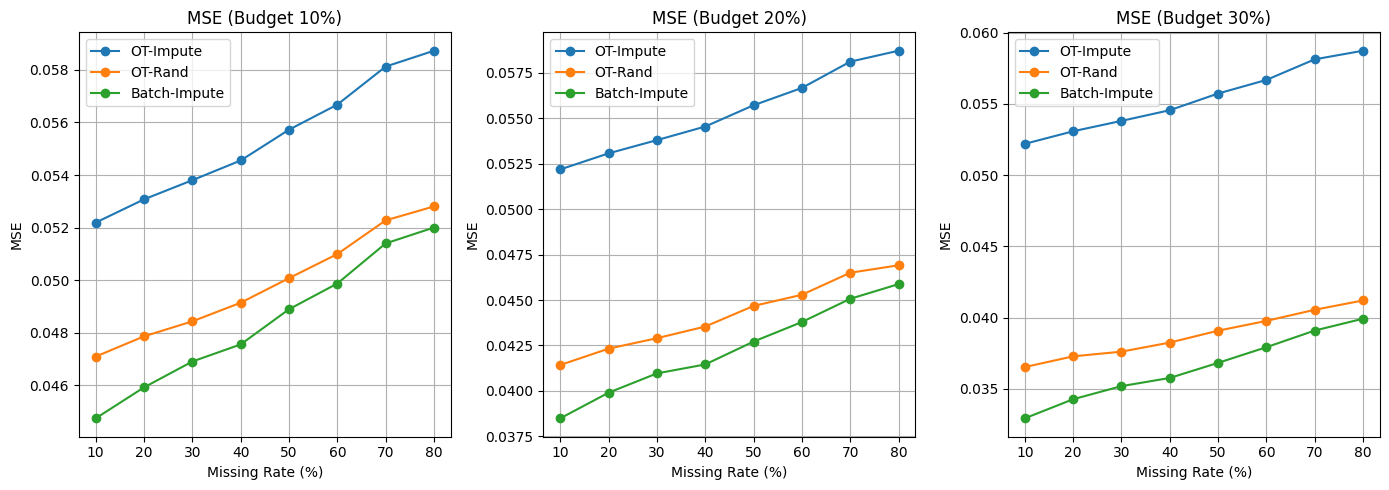

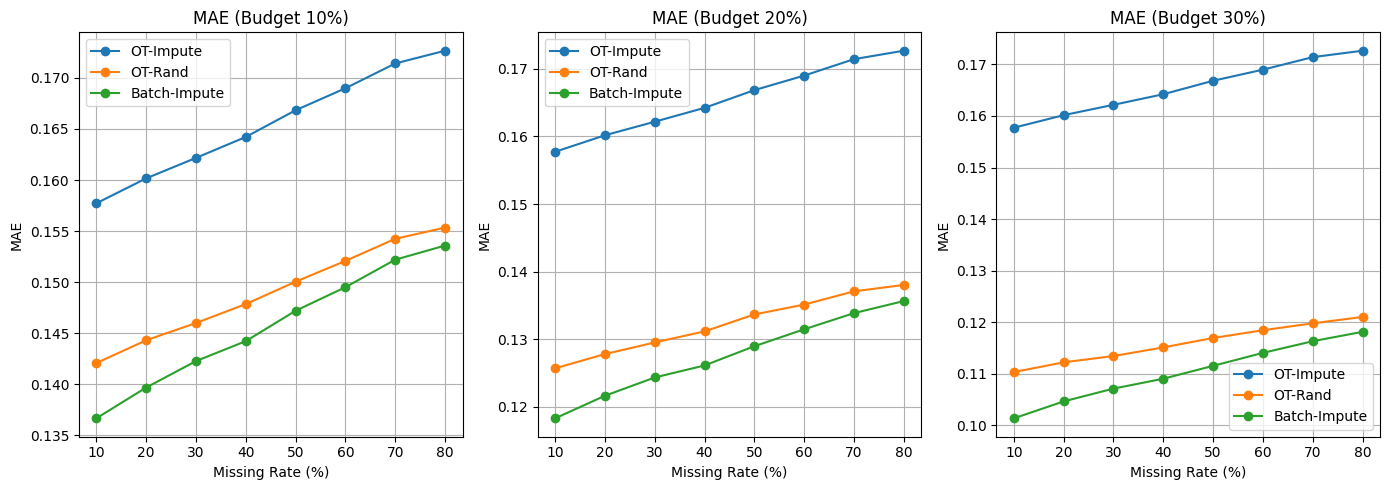

In [13]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

## MNAR

In [15]:
results_mnar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()

    imputed_runs = []
    for i in range(4):
        print(f"Run {i+1}...")
        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean = np.nanmean(imputed_stack, axis=0)
    imputed_std = np.nanstd(imputed_stack, axis=0)

    # Vanilla OTImputer (same for all budgets)
    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
        std_values = imputed_std[missing_mask.values]

        # Save Vanilla
        results_mnar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mnar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = imputed_mean.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mnar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mnar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)

rows = []  # Initialize or clear it

for metric in ["MSE", "MAE"]:
    for budget in results_mnar[metric]:
        for method in results_mnar[metric][budget]:
            values = results_mnar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })


#dataframe convertion
df_results_mnar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mnar = df_results_mnar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mnar.columns.name = None
df_results_mnar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mnar.columns]
df_results_mnar.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_results_mnar_metrics.csv", index=False)
    

Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
  -> Budget 20%
  -> Budget 30%



Plotting results...


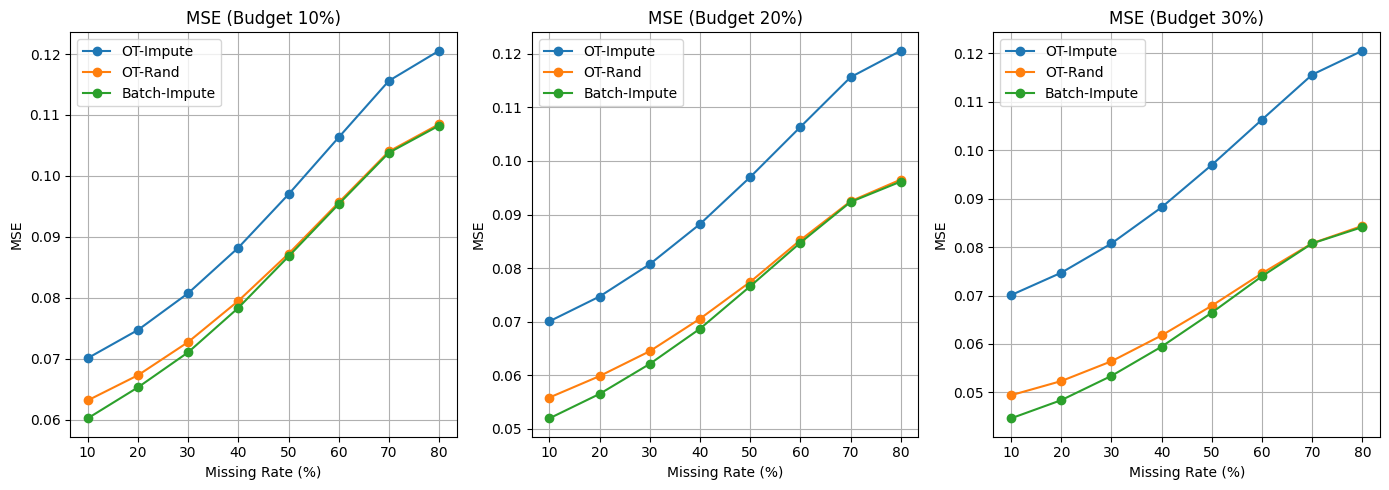

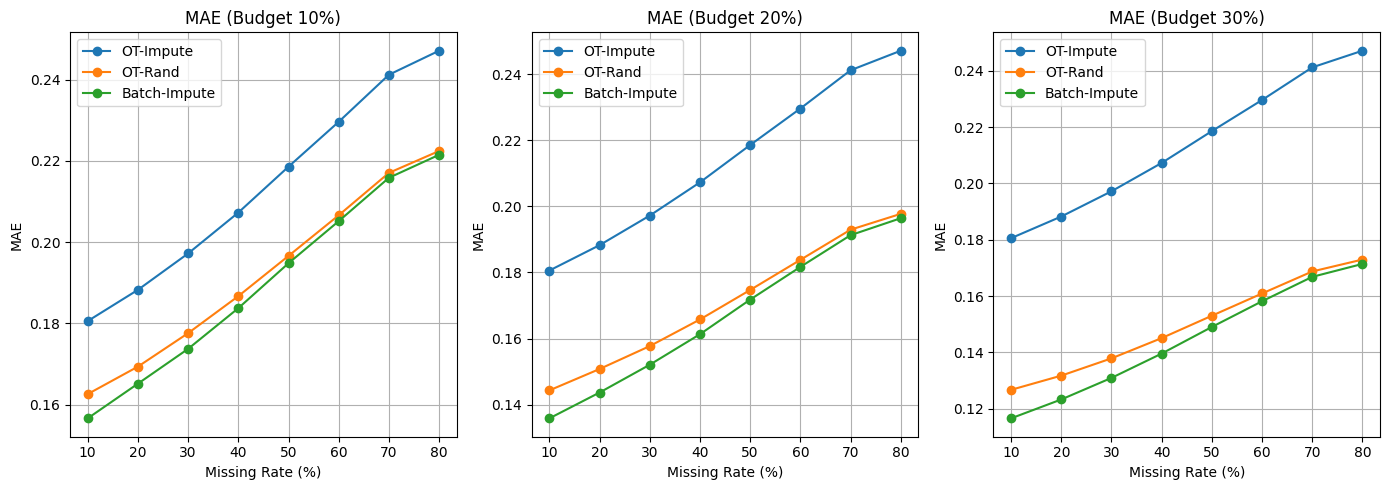

In [16]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

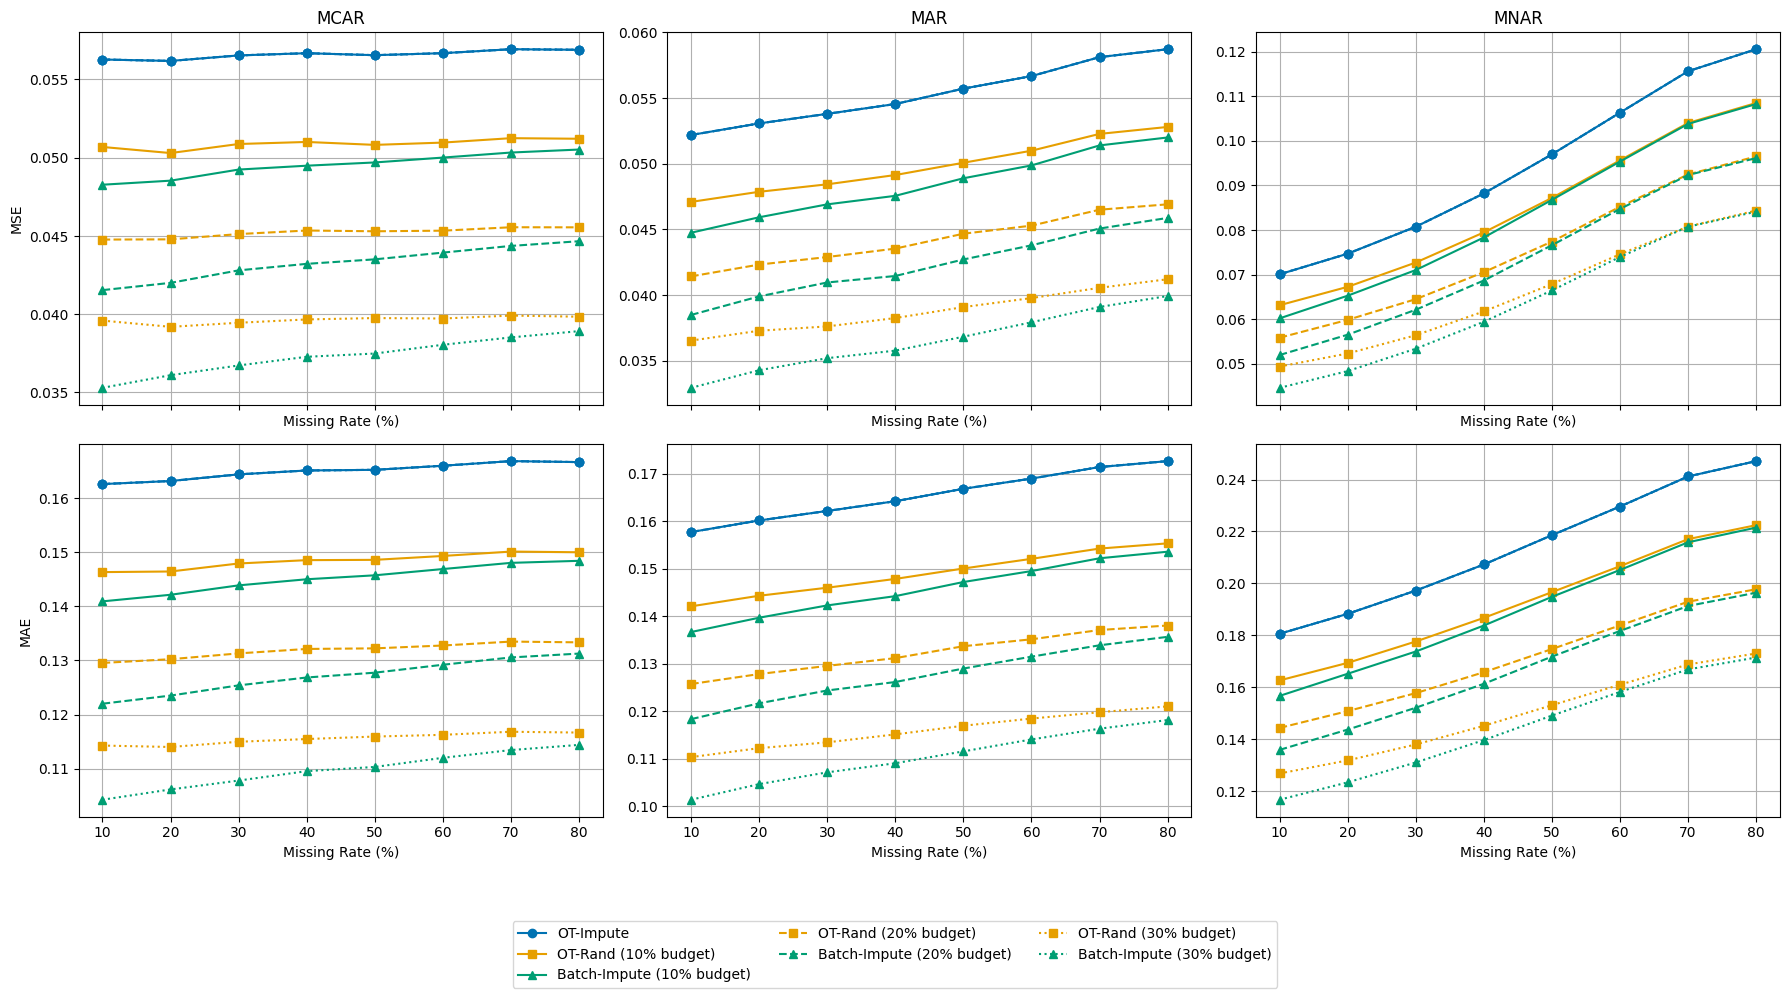

In [17]:
import matplotlib.pyplot as plt

# === Data Setup (replace these with your real data) ===
# Each pattern result should follow this format:
# results_*[metric]["budget_fraction"]["method"] = list of values
pattern_data = {
    "MCAR": results_mcar,
    "MAR": results_mar,
    "MNAR": results_mnar
}

missing_patterns = ["MCAR", "MAR", "MNAR"]
budgets = [0.1, 0.2, 0.3]
methods = ["OT-Impute", "OT-Rand", "Batch-Impute"]
missing_rates = [10, 20, 30, 40, 50, 60, 70, 80]  # Adjust as needed

# === Style Settings ===
line_styles = {0.1: '-', 0.2: '--', 0.3: ':'}
markers = {"OT-Impute": 'o', "OT-Rand": 's', "Batch-Impute": '^'}
colors = {"OT-Impute": '#0072B2', "OT-Rand": '#E69F00', "Batch-Impute": '#009E73'}  # colorblind-friendly

# === Optional: std values for error bands ===
# Format: std_data[pattern][metric][budget][method] = list of stds
# Set to None if not using
std_data = None  # or load your std_data dictionary here

# === Plotting ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

metrics = ["MSE", "MAE"]

vanilla_labeled = False

for row_idx, metric in enumerate(metrics):
    for col_idx, pattern in enumerate(missing_patterns):
        ax = axes[row_idx, col_idx]
    
        results = pattern_data[pattern]

        for budget in budgets:
            for method in methods:
                plot_method = "Batch-Impute" if method == "Batch-Impute" else method
                values = results[metric][budget][plot_method]

                if len(values) != len(missing_rates):
                    print(f"⚠️ Skipped: {pattern}, {metric}, {method}, budget {budget}")
                    continue

                # Plot mean line
                if method == "OT-Impute":
                    label = "OT-Impute" if not vanilla_labeled else None
                    vanilla_labeled = True
                else:
                    label = f"{method} ({int(budget * 100)}% budget)"

                

                ax.plot(
                    missing_rates,
                    values,
                    linestyle=line_styles[budget],
                    marker=markers[method],
                    color=colors[method],
                    label=label
                )


                # Optional: Error bands
                if std_data:
                    std_vals = std_data[pattern][metric][budget][method]
                    if len(std_vals) == len(values):
                        lower = [v - s for v, s in zip(values, std_vals)]
                        upper = [v + s for v, s in zip(values, std_vals)]
                        ax.fill_between(missing_rates, lower, upper, color=colors[method], alpha=0.2)

        if row_idx == 0:
            ax.set_title(pattern)
        if col_idx == 0:
            ax.set_ylabel(metric)
        ax.set_xlabel("Missing Rate (%)")
        ax.grid(True)

# === Shared Legend ===
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', bbox_to_anchor=(0.5, -0.05))

# === Main Title & Layout ===

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_matrix.pdf", bbox_inches='tight')

plt.show()


## Comarision

MCAR Budget 0.1

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.1
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mcar_b01 = []

num_runs = 5  # Repeat the whole process this many times

for run in range(num_runs):
    print(f"\n===== RUN {run + 1} / {num_runs} =====")
    for missing_rate in missing_rates:
        print(f"\n=== Missing Rate: {missing_rate}% ===")

        # Inject missing values
        generator = Inject_Missing_Values()
        X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
        missing_mask = X_missing.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * len(missing_positions))

        # Initialize imputers
        imputers = {
            "Mean": lambda df: df.fillna(df.mean()),
            "KNN": KNNImputer(n_neighbors=5),
            "MICE": IterativeImputer(max_iter=50, random_state=42),
            "OT-Impute": OTimputer(niter=100, batchsize=128)
        }

        mae_scores = {}

        # Basic Imputers
        for method in ["Mean", "KNN", "MICE", "OT-Impute"]:
            print(f"Running {method}...")
            try:
                if method == "Mean":
                    imputed = imputers[method](X_missing).values
                elif method == "OT-Impute":
                    Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                    imputed = imputers[method].fit_transform(Xt).detach().numpy()
                else:
                    imputed = imputers[method].fit_transform(X_missing)

                mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
                mae_scores[method] = round(mae, 4)
                all_results_comparision_mcar_b01.append({
                    "Run": run,
                    "MissingRate(%)": missing_rate,
                    "Method": method,
                    "MAE": round(mae, 4)
                })
            except Exception as e:
                print(f"Error in {method}: {e}")

        # OT-RandomFix
        print("Running OT-RandomFix...")
        imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
        rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
        rand_selected = missing_positions[rand_idx]
        X_random_fixed = imputed_ot.copy()
        for r, c in rand_selected:
            X_random_fixed[r, c] = GroundTruth.values[r, c]

        mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
        mae_scores["OT-Rand"] = round(mae_random, 4)
        all_results_comparision_mcar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "OT-Rand",
            "MAE": round(mae_random, 4)
        })

        # OT-ActiveOT (1-shot uncertainty)
        print("Running OT-ActiveOT...")
        runs = []
        for _ in range(4):
            Xt = torch.tensor(X_missing.values, dtype=torch.float64)
            runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

        stacked = np.stack(runs)
        mean_imp = np.mean(stacked, axis=0)
        std_imp = np.std(stacked, axis=0)
        std_vals = std_imp[missing_mask.values]
        top_idx = np.argsort(-std_vals)[:budget]
        active_selected = missing_positions[top_idx]
        X_active_fixed = mean_imp.copy()
        for r, c in active_selected:
            X_active_fixed[r, c] = GroundTruth.values[r, c]

        mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
        mae_scores["Batch-Impute"] = round(mae_active, 4)
        all_results_comparision_mcar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "Batch-Impute",
            "MAE": round(mae_active, 4)
        })

        # Print per-missing-rate result
        print("\n📊 MAE Comparison:")
        df_mae = pd.DataFrame([
            {"Method": k, "MAE": v} for k, v in mae_scores.items()
        ]).sort_values("MAE")
        print(df_mae.to_string(index=False))

# === Save all runs ===
df_comparision_mcar_b01 = pd.DataFrame(all_results_comparision_mcar_b01)
df_comparision_mcar_b01.to_csv(
    r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_mae_comparison_mcar_budget01_allruns.csv",
    index=False
)


===== RUN 1 / 5 =====

=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1179
        MICE 0.1383
Batch-Impute 0.1405
        Mean 0.1569
     OT-Rand 0.1625
   OT-Impute 0.1805

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1358
        MICE 0.1402
Batch-Impute 0.1422
        Mean 0.1576
     OT-Rand 0.1642
   OT-Impute 0.1825

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1438
         KNN 0.1464
        Mean 0.1580
     OT-Rand 0.1646
        MICE 0.1727
   OT-Impute 0.1836

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1446
         KNN 0.1533
        Mean 0.1578
        MICE 0.1630
     OT-Rand 0.1657
   OT-Impute 0.1839

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1458
         KNN 0.1578
        Mean 0.1580
        MICE 0.1632
     OT-Rand 0.1661
   OT-Impute 0.1846

=== Missing Rate: 60% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1463
        MICE 0.1568
         KNN 0.1576
        Mean 0.1576
     OT-Rand 0.1669
   OT-Impute 0.1853

=== Missing Rate: 70% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Meth

c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1438
         KNN 0.1480
        Mean 0.1580
     OT-Rand 0.1655
        MICE 0.1726
   OT-Impute 0.1836

=== Missing Rate: 40% ===
Running Mean...
Running KNN...


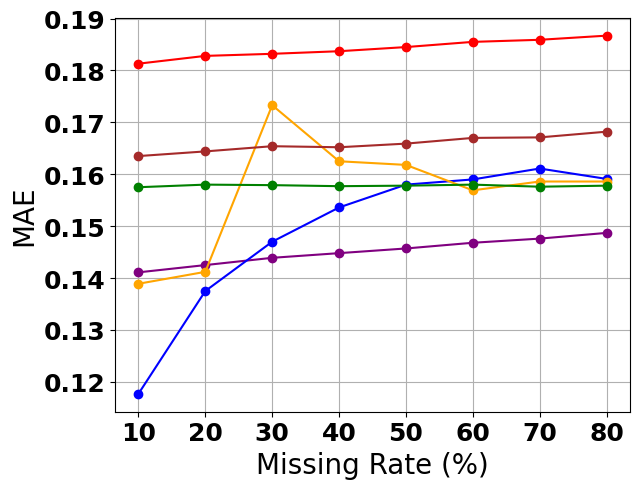

In [ ]:
import matplotlib.pyplot as plt
colors = {
    "KNN": "blue",
    "MICE": "orange",
    "Mean": "green",
    "OT-Impute": "red",
    "OT-Rand": "brown",
    "Batch-Impute": "purple"
}

# Set up the figure
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(6.5, 5))

# Loop through each method (all columns except the first)
for method in df_mae_summary_comparision_mcar_b01.columns[1:]:
    plt.plot(
        df_mae_summary_comparision_mcar_b01["MissingRate(%)"],
        df_mae_summary_comparision_mcar_b01[method],
        marker='o',
        label=method,
        color=colors[method]
    )



plt.xlabel("Missing Rate (%)", fontsize=20)

plt.ylabel("MAE", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.legend(loc='lower right', fontsize=14)


for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_comparision_mcar_b01.pdf",
            format="pdf", bbox_inches="tight")

plt.show()

# Final formatting
#plt.title("MAE vs Missing Rate for Different Imputation Methods")
#plt.xlabel("Missing Rate (%)")
#plt.ylabel("Mean Absolute Error (MAE)")


MCAR Budget 0.2

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.2
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mcar_b02 = []

for missing_rate in missing_rates:
    print(f"\n=== Missing Rate: {missing_rate}% ===")

    # Inject missing values
    generator = Inject_Missing_Values()
    X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
    missing_mask = X_missing.isna()
    missing_positions = np.argwhere(missing_mask.values)
    budget = int(budget_fraction * len(missing_positions))

    # Initialize imputers
    imputers = {
        "Mean": lambda df: df.fillna(df.mean()),
        "KNN": KNNImputer(n_neighbors=5),
        "MICE": IterativeImputer(max_iter=50, random_state=42),
        "OT-Impute": OTimputer(niter=100, batchsize=128)
    }

    mae_scores = {}

    # Basic Imputers
    for method in ["Mean", "KNN", "MICE", "OT"]:
        print(f"Running {method}...")
        try:
            if method == "Mean":
                imputed = imputers[method](X_missing).values
            elif method == "OT-Impute":
                Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                imputed = imputers[method].fit_transform(Xt).detach().numpy()
            else:
                imputed = imputers[method].fit_transform(X_missing)

            mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
            mae_scores[method] = round(mae, 4)
            all_results_comparision_mcar_b02.append({
                "MissingRate(%)": missing_rate,
                "Method": method,
                "MAE": round(mae, 4)
            })
        except Exception as e:
            print(f"Error in {method}: {e}")

    # OT-RandomFix
    print("Running OT-RandomFix...")
    imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
    rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
    rand_selected = missing_positions[rand_idx]
    X_random_fixed = imputed_ot.copy()
    for r, c in rand_selected:
        X_random_fixed[r, c] = GroundTruth.values[r, c]

    mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    mae_scores["OT-Rand"] = round(mae_random, 4)
    all_results_comparision_mcar_b02.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-Rand",
        "MAE": round(mae_random, 4)
    })

    # OT-ActiveOT (1-shot uncertainty)
    print("Running OT-ActiveOT...")
    runs = []
    for _ in range(4):
        Xt = torch.tensor(X_missing.values, dtype=torch.float64)
        runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

    stacked = np.stack(runs)
    mean_imp = np.mean(stacked, axis=0)
    std_imp = np.std(stacked, axis=0)
    std_vals = std_imp[missing_mask.values]
    top_idx = np.argsort(-std_vals)[:budget]
    active_selected = missing_positions[top_idx]
    X_active_fixed = mean_imp.copy()
    for r, c in active_selected:
        X_active_fixed[r, c] = GroundTruth.values[r, c]

    mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    mae_scores["Batch-Impute"] = round(mae_active, 4)
    all_results_comparision_mcar_b02.append({
        "MissingRate(%)": missing_rate,
        "Method": "Batch-Impute",
        "MAE": round(mae_active, 4)
    })

    # Print per-missing-rate result
    print("\n📊 MAE Comparison:")
    df_mae = pd.DataFrame([
        {"Method": k, "MAE": v} for k, v in mae_scores.items()
    ]).sort_values("MAE")
    print(df_mae.to_string(index=False))

# === After all missing rates ===
df_comparision_mcar_b02 = pd.DataFrame(all_results_comparision_mcar_b02)
df_mae_summary_comparision_mcar_b02 = df_comparision_mcar_b02.pivot(index="MissingRate(%)", columns="Method", values="MAE").reset_index()

print("\n📈 Full MAE Table Across Missing Rates:")
print(df_mae_summary_comparision_mcar_b02 .to_string(index=False))
df_mae_summary_comparision_mcar_b02.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_mae_comparison_mcar_budget02.csv", index=False)




=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Error in OT: 'OT'
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1182
Batch-Impute 0.1214
        MICE 0.1385
     OT-Rand 0.1450
        Mean 0.1575

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT...
Error in OT: 'OT'
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1240
         KNN 0.1351
        MICE 0.1405
     OT-Rand 0.1461
        Mean 0.1579

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT...
Error in OT: 'OT'
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1256
     OT-Rand 0.1460
         KNN 0.1479
        Mean 0.1579
        MICE 0.1728

=== Missing Rate: 40% ===
Running Mean...
Running KNN...


In [ ]:
import matplotlib.pyplot as plt
colors = {
    "KNN": "blue",
    "MICE": "orange",
    "Mean": "green",
    "OT-Impute": "red",
    "OT-RandomFix": "brown",
    "OT-OneShot": "purple"
}

# Set up the figure
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(6.5, 5))

# Loop through each method (all columns except the first)
for method in df_mae_summary_comparision_mcar_b02.columns[1:]:
    plt.plot(
        df_mae_summary_comparision_mcar_b02["MissingRate(%)"],
        df_mae_summary_comparision_mcar_b02[method],
        marker='o',
        label=method,
        color=colors[method]
    )



plt.xlabel("Missing Rate (%)", fontsize=20)

plt.ylabel("MAE", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.legend(loc='lower right', fontsize=14)


for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_comparision_mcar_b02.pdf",
            format="pdf", bbox_inches="tight")

plt.show()

# Final formatting
#plt.title("MAE vs Missing Rate for Different Imputation Methods")
#plt.xlabel("Missing Rate (%)")
#plt.ylabel("Mean Absolute Error (MAE)")


MCAR Budget 0.3

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.3
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mcar_b03 = []

for missing_rate in missing_rates:
    print(f"\n=== Missing Rate: {missing_rate}% ===")

    # Inject missing values
    generator = Inject_Missing_Values()
    X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
    missing_mask = X_missing.isna()
    missing_positions = np.argwhere(missing_mask.values)
    budget = int(budget_fraction * len(missing_positions))

    # Initialize imputers
    imputers = {
        "Mean": lambda df: df.fillna(df.mean()),
        "KNN": KNNImputer(n_neighbors=5),
        "MICE": IterativeImputer(max_iter=50, random_state=42),
        "OT-Impute": OTimputer(niter=100, batchsize=128)
    }

    mae_scores = {}

    # Basic Imputers
    for method in ["Mean", "KNN", "MICE", "OT"]:
        print(f"Running {method}...")
        try:
            if method == "Mean":
                imputed = imputers[method](X_missing).values
            elif method == "OT-Impute":
                Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                imputed = imputers[method].fit_transform(Xt).detach().numpy()
            else:
                imputed = imputers[method].fit_transform(X_missing)

            mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
            mae_scores[method] = round(mae, 4)
            all_results_comparision_mcar_b03.append({
                "MissingRate(%)": missing_rate,
                "Method": method,
                "MAE": round(mae, 4)
            })
        except Exception as e:
            print(f"Error in {method}: {e}")

    # OT-RandomFix
    print("Running OT-RandomFix...")
    imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
    rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
    rand_selected = missing_positions[rand_idx]
    X_random_fixed = imputed_ot.copy()
    for r, c in rand_selected:
        X_random_fixed[r, c] = GroundTruth.values[r, c]

    mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    mae_scores["OT-Rand"] = round(mae_random, 4)
    all_results_comparision_mcar_b03.append({
        "MissingRate(%)": missing_rate,
        "Method": "OT-Rand",
        "MAE": round(mae_random, 4)
    })

    # OT-ActiveOT (1-shot uncertainty)
    print("Running OT-ActiveOT...")
    runs = []
    for _ in range(4):
        Xt = torch.tensor(X_missing.values, dtype=torch.float64)
        runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

    stacked = np.stack(runs)
    mean_imp = np.mean(stacked, axis=0)
    std_imp = np.std(stacked, axis=0)
    std_vals = std_imp[missing_mask.values]
    top_idx = np.argsort(-std_vals)[:budget]
    active_selected = missing_positions[top_idx]
    X_active_fixed = mean_imp.copy()
    for r, c in active_selected:
        X_active_fixed[r, c] = GroundTruth.values[r, c]

    mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    mae_scores["Batch-Impute"] = round(mae_active, 4)
    all_results_comparision_mcar_b03.append({
        "MissingRate(%)": missing_rate,
        "Method": "Batch-Impute",
        "MAE": round(mae_active, 4)
    })

    # Print per-missing-rate result
    print("\n📊 MAE Comparison:")
    df_mae = pd.DataFrame([
        {"Method": k, "MAE": v} for k, v in mae_scores.items()
    ]).sort_values("MAE")
    print(df_mae.to_string(index=False))

# === After all missing rates ===
df_comparision_mcar_b03 = pd.DataFrame(all_results_comparision_mcar_b03)
df_mae_summary_comparision_mcar_b03 = df_comparision_mcar_b03.pivot(index="MissingRate(%)", columns="Method", values="MAE").reset_index()

print("\n📈 Full MAE Table Across Missing Rates:")
print(df_mae_summary_comparision_mcar_b03 .to_string(index=False))
df_mae_summary_comparision_mcar_b03.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_mae_comparison_mcar_budget03.csv", index=False)



In [ ]:
import matplotlib.pyplot as plt
colors = {
    "KNN": "blue",
    "MICE": "orange",
    "Mean": "green",
    "OT-Impute": "red",
    "OT-Rand": "brown",
    "Batch-Impute": "purple"
}

# Set up the figure
#plt.figure(figsize=(10, 6))
plt.figure(figsize=(6.5, 5))

# Loop through each method (all columns except the first)
for method in df_mae_summary_comparision_mcar_b03.columns[1:]:
    plt.plot(
        df_mae_summary_comparision_mcar_b03["MissingRate(%)"],
        df_mae_summary_comparision_mcar_b03[method],
        marker='o',
        label=method,
        color=colors[method]
    )



plt.xlabel("Missing Rate (%)", fontsize=20)

plt.ylabel("MAE", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
#plt.legend(loc='lower right', fontsize=14)


for label in plt.gca().get_xticklabels():
    label.set_fontweight('bold')
for label in plt.gca().get_yticklabels():
    label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_comparision_mcar_b03.pdf",
            format="pdf", bbox_inches="tight")
plt.show()

# Final formatting
#plt.title("MAE vs Missing Rate for Different Imputation Methods")
#plt.xlabel("Missing Rate (%)")
#plt.ylabel("Mean Absolute Error (MAE)")


## Optimization

MCAR


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


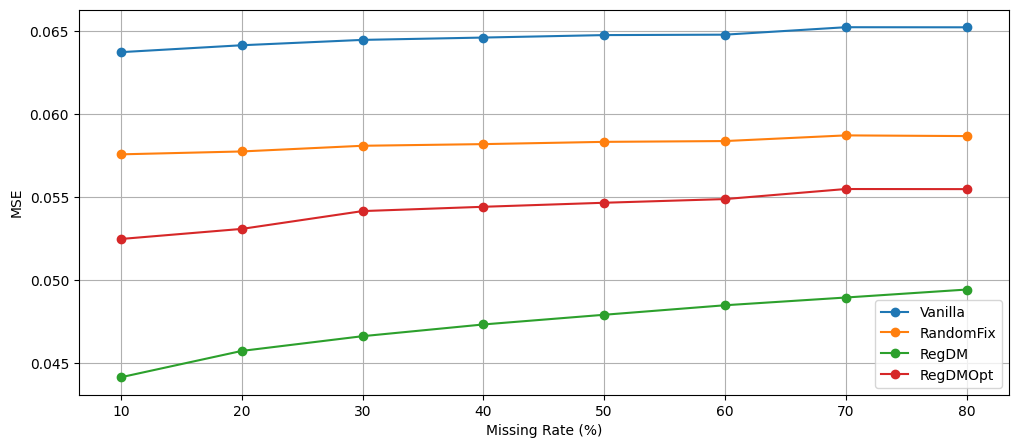

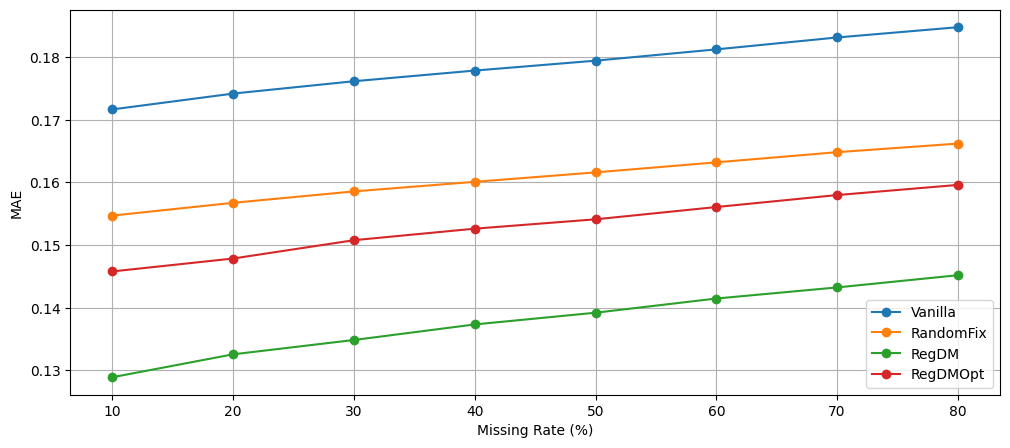

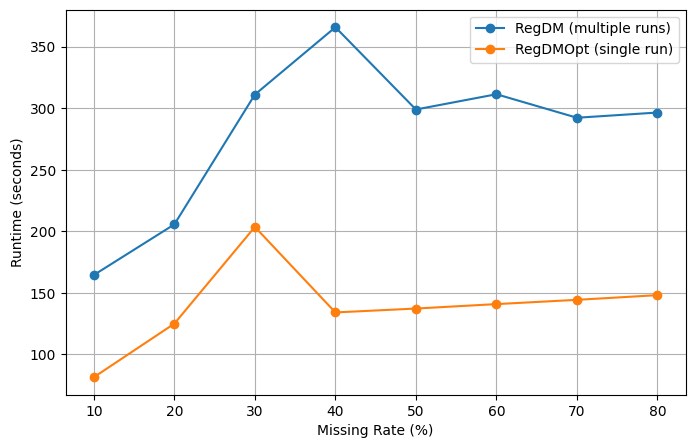

In [ ]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "MAE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "Time": {"Batch-Impute": [], "BatchOpt-Impute": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=100, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["OT-Impute"].append(baseline_mse)
    results_mcar_opt["MAE"]["OT-Impute"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["OT-Rand"].append(random_fix_mse)
    results_mcar_opt["MAE"]["OT-Rand"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["Batch-Impute"].append(active_fix_mse)
    results_mcar_opt["MAE"]["Batch-Impute"].append(active_fix_mae)
    results_mcar_opt["Time"]["Batch-Impute"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=500,
        batchsize=128,
        dropout_noise_scale= 0.005
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval = 10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["BatchOpt-Impute"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["BatchOpt-Impute"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["BatchOpt-Impute"].append(activeotopt_time)

mse_df = pd.DataFrame(results_mcar_opt["MSE"])
mse_df.insert(0, "MissingRate", missing_rates)
mse_df.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_MCAR_OPT_Results_MSE.csv", index=False)

# Save MAE results
mae_df = pd.DataFrame(results_mcar_opt["MAE"])
mae_df.insert(0, "MissingRate", missing_rates)
mae_df.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_MCAR_OPT_Results_MAE.csv", index=False)

# Save Runtime results
time_df = pd.DataFrame(results_mcar_opt["Time"])
time_df.insert(0, "MissingRate", missing_rates)
time_df.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_MCAR_OPT_Results_Time.csv", index=False)



# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "BatchOpt-Impute"]:
    plt.plot(missing_rates, results_mcar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
#plt.title("MSE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MCAR_OptComparision_MAE.pdf", bbox_inches='tight')
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mcar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
#plt.title("MAE vs Missing Rate (MCAR) Adult Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MCAR_OptComparision_MSE.pdf", bbox_inches='tight')
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mcar_opt["Time"]["RegDM"], label="RegDM (multiple runs)", marker='o')
plt.plot(missing_rates, results_mcar_opt["Time"]["RegDMOpt"], label="RegDMOpt (single run)", marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
#plt.title("Runtime Comparison (MCAR) Adult Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MCAR_OptComparision_time.pdf", bbox_inches='tight')
plt.show()



In [188]:
missing_rate = 30  # 10% to 90%
budget_fractions = 0.1  # fixed 10%
dropOutNoises = [ 0, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]


results_mcar_opt_dropuOut = {d: [] for d in dropOutNoises}
n_runs = 10  # or 10


for dropOutNoise in dropOutNoises:
    print(f"\n=== Dropout Noise: {dropOutNoise} ===")
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}")
        
        generator_mcar = Inject_Missing_Values()
        miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
        missing_mask = miss_mcar.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * missing_mask.values.sum())

        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputerDropOutNoise(
            niter=300,
            batchsize=128,
            dropout_noise_scale=dropOutNoise
        )
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
            X_missing_tensor, track_confidence=True, snapshot_interval=10
        )

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()
        top_indices_opt = np.argsort(-std_values_opt)[:budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values]
        )
        results_mcar_opt_dropuOut[dropOutNoise].append(mae)



=== Dropout Noise: 0 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.01 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Nois

MAR


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


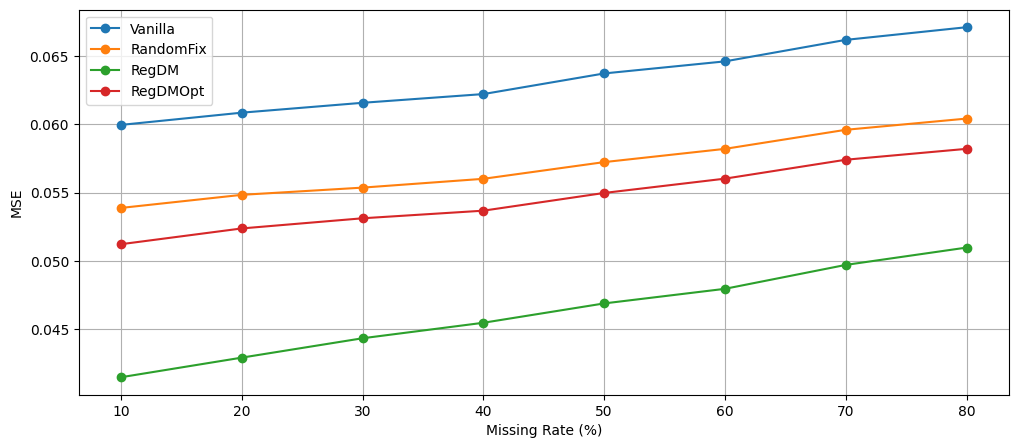

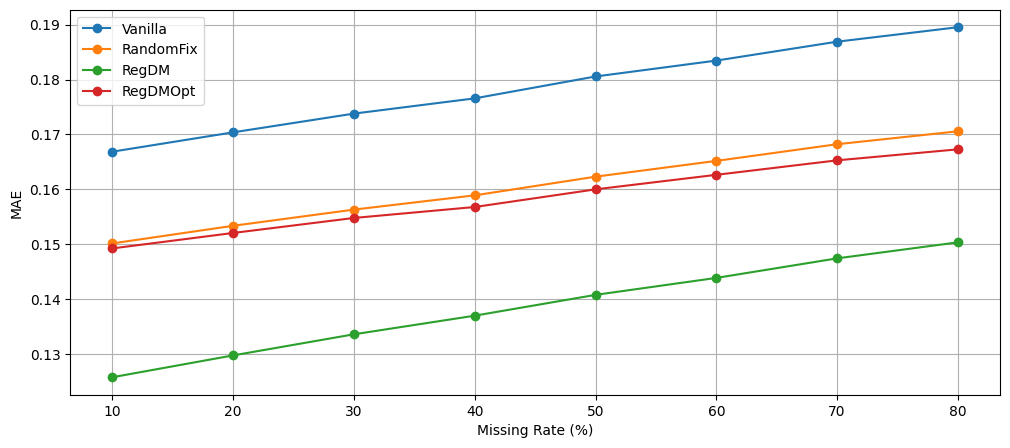

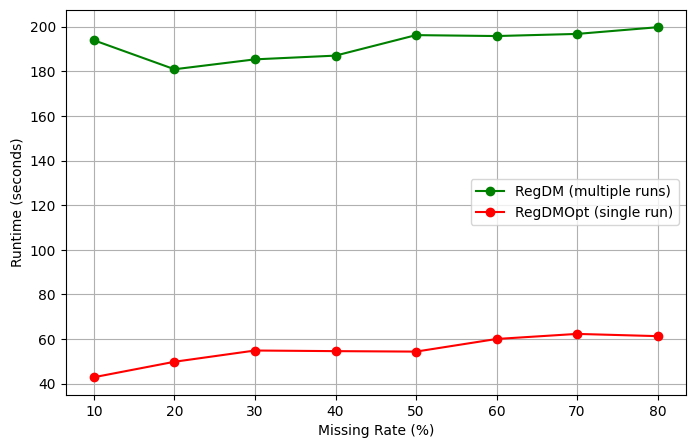

In [ ]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "Time": {"RegDM": [], "RegDMOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    missing_mask = miss_mar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mar_opt["MSE"]["RegDM"].append(active_fix_mse)
    results_mar_opt["MAE"]["RegDM"].append(active_fix_mae)
    results_mar_opt["Time"]["RegDM"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale=0.001 # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mar_opt["MSE"]["RegDMOpt"].append(activeopt_fix_mse)
    results_mar_opt["MAE"]["RegDMOpt"].append(activeopt_fix_mae)
    results_mar_opt["Time"]["RegDMOpt"].append(activeotopt_time)

mse_df = pd.DataFrame(results_mar_opt["MSE"])
mse_df.insert(0, "MissingRate", missing_rates)
mse_df.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_MAR_OPT_Results_MSE.csv", index=False)

# Save MAE results
mae_df = pd.DataFrame(results_mar_opt["MAE"])
mae_df.insert(0, "MissingRate", missing_rates)
mae_df.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_MAR_OPT_Results_MAE.csv", index=False)

# Save Runtime results
time_df = pd.DataFrame(results_mar_opt["Time"])
time_df.insert(0, "MissingRate", missing_rates)
time_df.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_MAR_OPT_Results_Time.csv", index=False)



# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
#plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MAR_OptComparision_MSE.pdf", bbox_inches='tight')
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
#plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()

plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MAR_OptComparision_MAE.pdf", bbox_inches='tight')
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mar_opt["Time"]["RegDM"], label="RegDM (multiple runs)", marker='o',color = 'green')
plt.plot(missing_rates, results_mar_opt["Time"]["RegDMOpt"], label="RegDMOpt (single run)", marker='o',color = 'red')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
#plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MAR_OptComparision_time.pdf", bbox_inches='tight')
plt.show()



MNAR


=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===

Plotting results...


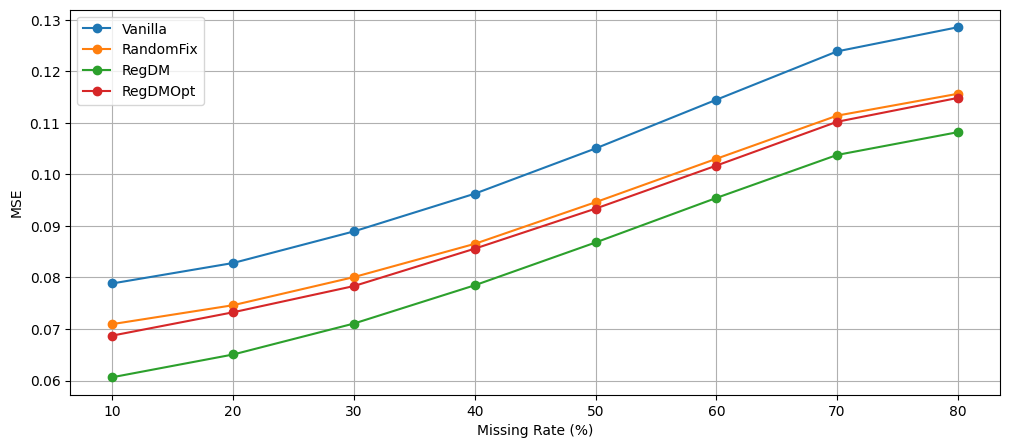

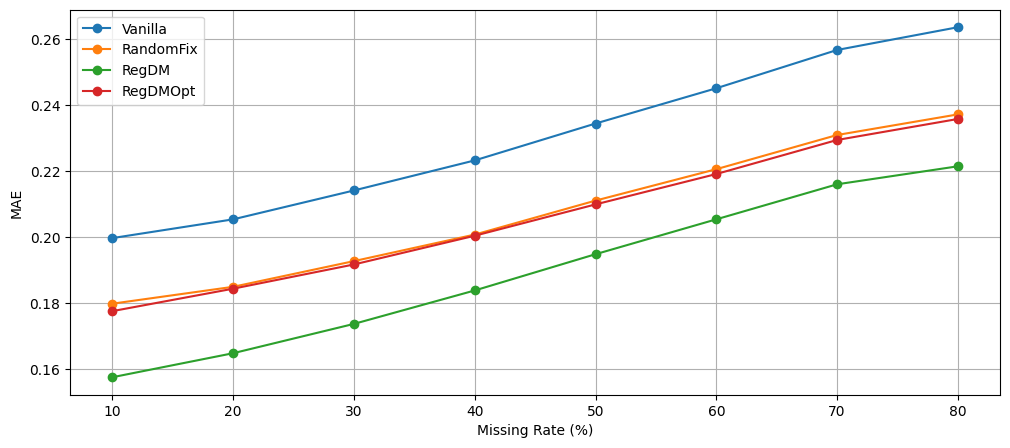

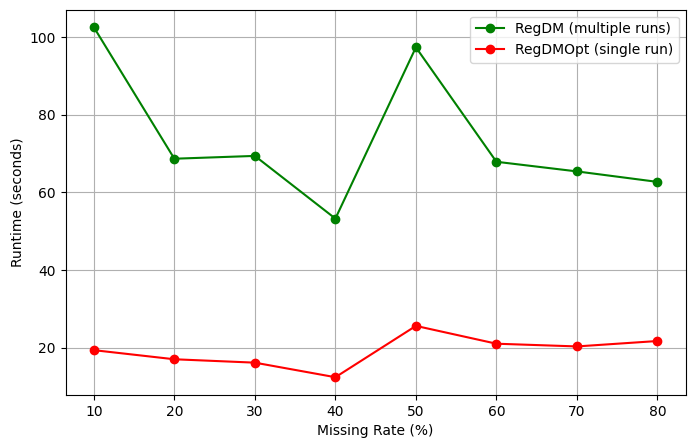

In [ ]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mnar_opt = {
    "MSE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "MAE": {"Vanilla": [], "RandomFix": [], "RegDM": [], "RegDMOpt": []},
    "Time": {"RegDM": [], "RegDMOpt": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mnar_opt["MSE"]["Vanilla"].append(baseline_mse)
    results_mnar_opt["MAE"]["Vanilla"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mnar_opt["MSE"]["RandomFix"].append(random_fix_mse)
    results_mnar_opt["MAE"]["RandomFix"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mnar_opt["MSE"]["RegDM"].append(active_fix_mse)
    results_mnar_opt["MAE"]["RegDM"].append(active_fix_mae)
    results_mnar_opt["Time"]["RegDM"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale=0.001 # Injecting small noise
    )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()
    #print( std_values_opt)

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    #print(top_indices_opt)
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mnar_opt["MSE"]["RegDMOpt"].append(activeopt_fix_mse)
    results_mnar_opt["MAE"]["RegDMOpt"].append(activeopt_fix_mae)
    results_mnar_opt["Time"]["RegDMOpt"].append(activeotopt_time)

mse_df = pd.DataFrame(results_mnar_opt["MSE"])
mse_df.insert(0, "MissingRate", missing_rates)
mse_df.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_MNAR_OPT_Results_MSE.csv", index=False)

# Save MAE results
mae_df = pd.DataFrame(results_mnar_opt["MAE"])
mae_df.insert(0, "MissingRate", missing_rates)
mae_df.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_MNAR_OPT_Results_MAE.csv", index=False)

# Save Runtime results
time_df = pd.DataFrame(results_mnar_opt["Time"])
time_df.insert(0, "MissingRate", missing_rates)
time_df.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_MNAR_OPT_Results_Time.csv", index=False)



# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

# Plot MSE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mnar_opt["MSE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MSE")
#plt.title("MSE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MNAR_OptComparision_MSE.pdf", bbox_inches='tight')
plt.show()

# Plot MAE
plt.figure(figsize=(12,5))
for method in ["Vanilla", "RandomFix", "RegDM", "RegDMOpt"]:
    plt.plot(missing_rates, results_mnar_opt["MAE"][method], label=method, marker='o')
plt.xlabel("Missing Rate (%)")
plt.ylabel("MAE")
#plt.title("MAE vs Missing Rate (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MNAR_OptComparision_MAE.pdf", bbox_inches='tight')
plt.show()

# Plot Runtime (ActiveOT vs ActiveOTOpt)
plt.figure(figsize=(8,5))
plt.plot(missing_rates, results_mnar_opt["Time"]["RegDM"], label="RegDM (multiple runs)", marker='o',color = 'green')
plt.plot(missing_rates, results_mnar_opt["Time"]["RegDMOpt"], label="RegDMOpt (single run)", marker='o',color = 'red')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Runtime (seconds)")
#plt.title("Runtime Comparison (MCAR) Wine Data")
plt.legend()
plt.grid(True)
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MNAR_OptComparision_time.pdf", bbox_inches='tight')
plt.show()



## Fully Active

In [176]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 10,      # match ACM font size
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "text.latex.preamble": r"\usepackage{times}"  # ACM uses Times
})


MCAR Budget 0.1

In [67]:
generator_mcar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MCAR(X,missing_rate=30)
mask = X_missing.isna()

results_fullyActive_mcar = []
max_k = 4
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mcar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mcar= pd.DataFrame(results_fullyActive_mcar)
print("\nFinal Results:")
print(df_iter_mcar)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.27546444568489964
    Avg Std of Queried Cells: 0.1464
    Intermediate MAE after iteration 1: 0.1489
  Final MAE: 0.1489, Time: 11.84s, Unique Queried: 20513, Avg Std: 0.1464

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2832126832519905
    Avg Std of Queried Cells: 0.1592
    Intermediate MAE after iteration 1: 0.1578
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non

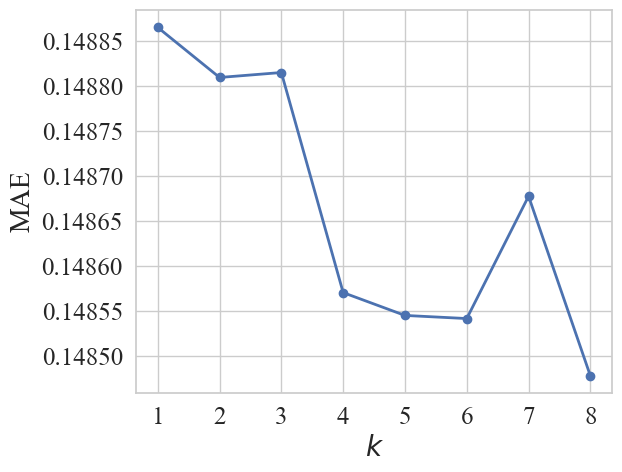

In [180]:
plt.figure(figsize=(6.5, 5))
  # Wider and taller

plt.plot(df_iter_mcar['k'], df_iter_mcar['MAE'], marker='o')

plt.xlabel(r"$k$", fontsize=20,fontweight='normal')

plt.ylabel("MAE", fontsize=20,fontweight='normal')

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

#for label in plt.gca().get_xticklabels():
    #label.set_fontweight('bold')
#for label in plt.gca().get_yticklabels():
    #label.set_fontweight('bold')

plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MAEVSNumberOfIteration_budget0.1_mcar.pdf",
            format="pdf", bbox_inches="tight")
plt.show()


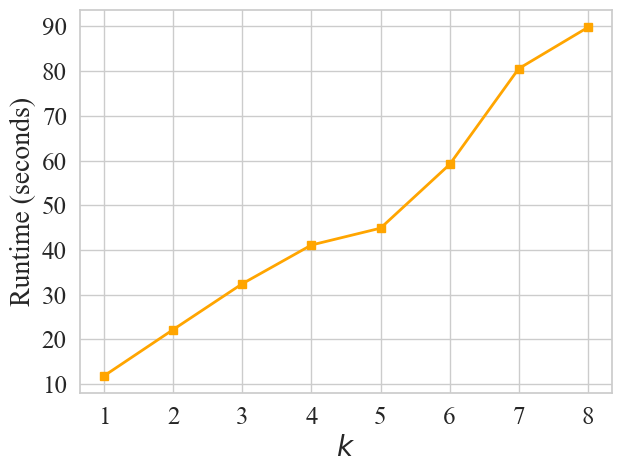

In [183]:
plt.figure(figsize=(6.5, 5))
plt.plot(df_iter_mcar['k'], df_iter_mcar['Runtime'], marker='s', color='orange', label='Runtime')

plt.xlabel(r"${k}$", fontsize=20,fontweight='normal')
plt.ylabel("Runtime (seconds)",fontsize=20,fontweight='normal')


plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

#for label in plt.gca().get_xticklabels():
    #label.set_fontweight('bold')
#for label in plt.gca().get_yticklabels():
    #label.set_fontweight('bold')

plt.grid(True)
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_RuntimeVSNumberOfIteration_budget0.1_mcar.pdf",
            format="pdf", bbox_inches="tight")
plt.show()


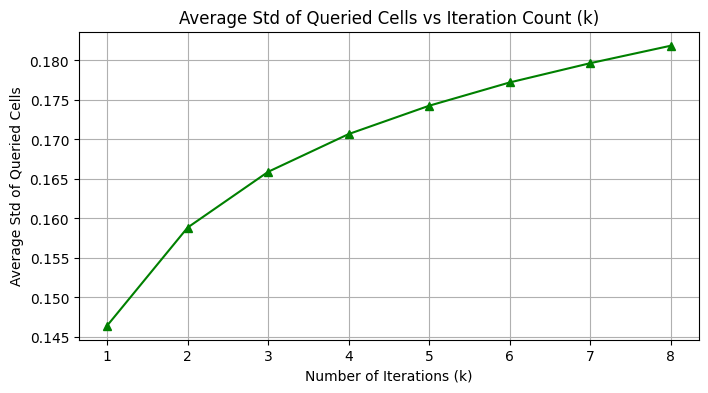

In [85]:
# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

MCAR Budget 0.2

In [78]:
generator_mcar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MCAR(X,missing_rate=30)
mask = X_missing.isna()

results_fullyActive_mcar_b2 = []
max_k = 4
budget_fraction = 0.2
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mcar_b2.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mcar_b2= pd.DataFrame(results_fullyActive_mcar_b2)
print("\nFinal Results:")
print(df_iter_mcar_b2)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.282869069195922
    Avg Std of Queried Cells: 0.1313
    Intermediate MAE after iteration 1: 0.1323
  Final MAE: 0.1323, Time: 17.42s, Unique Queried: 41027, Avg Std: 0.1313

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2543605439326193
    Avg Std of Queried Cells: 0.1464
    Intermediate MAE after iteration 1: 0.1494
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-z

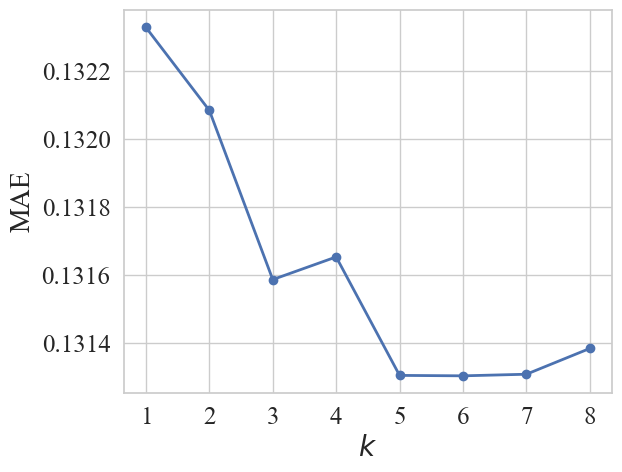

In [184]:
plt.figure(figsize=(6.5, 5))
  # Wider and taller

plt.plot(df_iter_mcar_b2['k'], df_iter_mcar_b2['MAE'], marker='o')

plt.xlabel(r"${k}$", fontsize=20,fontweight=True)

plt.ylabel("MAE", fontsize=20,fontweight=True)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

#for label in plt.gca().get_xticklabels():
    #label.set_fontweight('bold')
#for label in plt.gca().get_yticklabels():
    #label.set_fontweight('bold')


plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MAEVSNumberOfIteration_budget0.2_mcar.pdf",
            format="pdf", bbox_inches="tight")
plt.show()


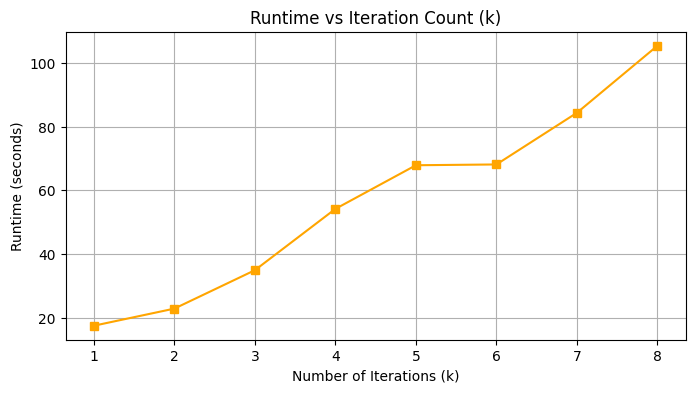

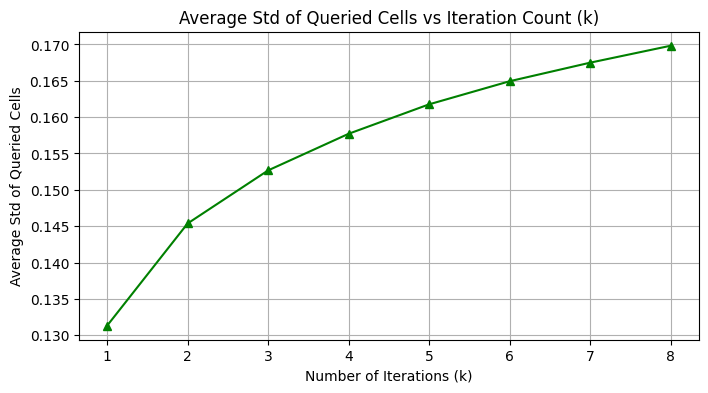

In [87]:
# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar_b2['k'], df_iter_mcar_b2['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar_b2['k'], df_iter_mcar_b2['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

MCAR Budget 0.3

In [80]:
generator_mcar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MCAR(X,missing_rate=30)
mask = X_missing.isna()

results_fullyActive_mcar_b3 = []
max_k = 4
budget_fraction = 0.3
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mcar_b3.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mcar_b3= pd.DataFrame(results_fullyActive_mcar_b3)
print("\nFinal Results:")
print(df_iter_mcar_b3)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2556177368371169
    Avg Std of Queried Cells: 0.1218
    Intermediate MAE after iteration 1: 0.1153
  Final MAE: 0.1153, Time: 16.82s, Unique Queried: 61540, Avg Std: 0.1218

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2762786600477956
    Avg Std of Queried Cells: 0.1376
    Intermediate MAE after iteration 1: 0.1406
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-

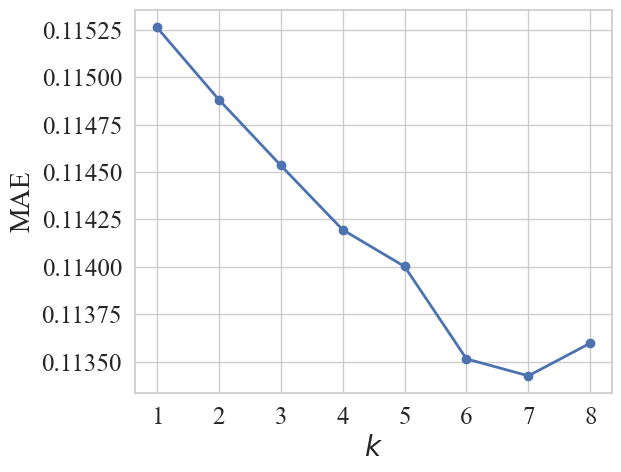

In [187]:
plt.figure(figsize=(6.5, 5))
  # Wider and taller

plt.plot(df_iter_mcar_b3['k'], df_iter_mcar_b3['MAE'], marker='o')

plt.xlabel(r"${k}$", fontsize=20,fontweight='normal')

plt.ylabel("MAE", fontsize=20,fontweight='normal')

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

#for label in plt.gca().get_xticklabels():
    #label.set_fontweight('bold')
#for label in plt.gca().get_yticklabels():
    #label.set_fontweight('bold')


plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MAEVSNumberOfIteration_budget0.3_mcar.pdf",
            format="pdf", bbox_inches="tight")
plt.show()


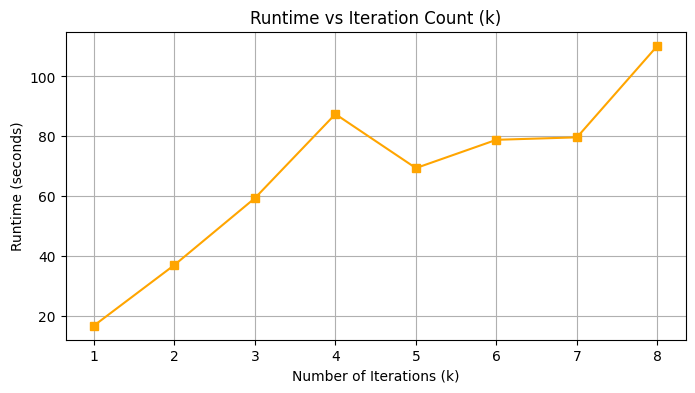

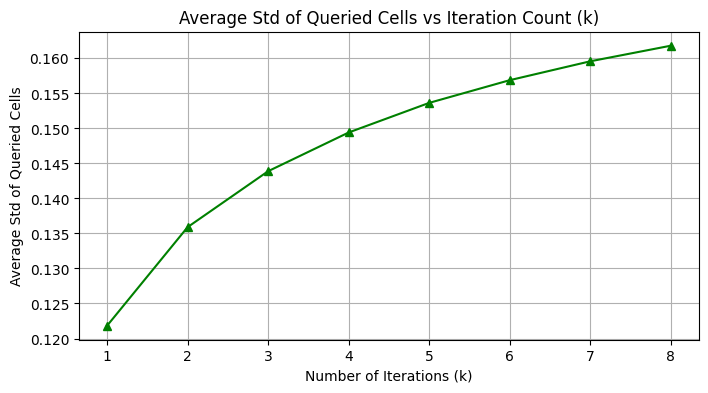

In [88]:
# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar_b3['k'], df_iter_mcar_b3['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar_b3['k'], df_iter_mcar_b3['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

MAR

In [69]:
generator_mar = Inject_Missing_Values()
X_missing, index_mar = generator_mar.MAR(X,missing_rate=30, dependencies = dependencies_mar)
mask = X_missing.isna()

results_fullyActive_mar = []
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mar = pd.DataFrame(results_fullyActive_mar)
print("\nFinal Results:")
print(df_iter_mar)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.36055470058033967
    Avg Std of Queried Cells: 0.1461
    Intermediate MAE after iteration 1: 0.1474
  Final MAE: 0.1474, Time: 11.34s, Unique Queried: 20513, Avg Std: 0.1461

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.27599415600441707
    Avg Std of Queried Cells: 0.1590
    Intermediate MAE after iteration 1: 0.1557
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (no

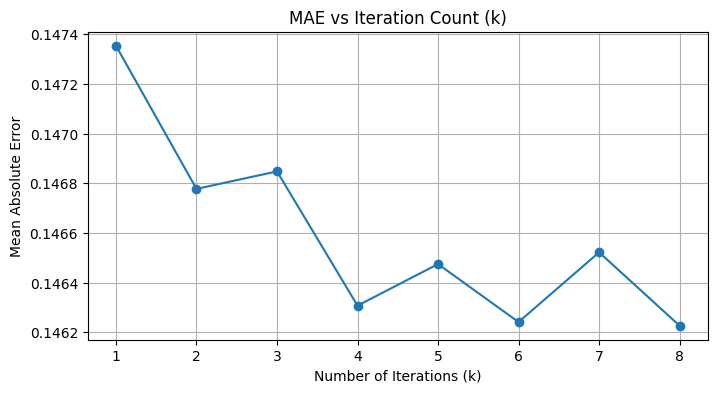

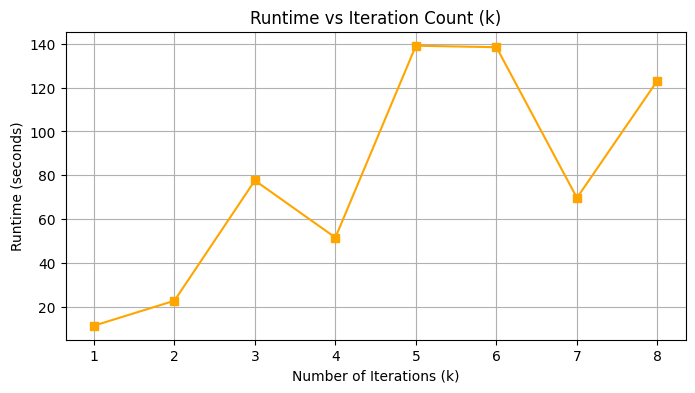

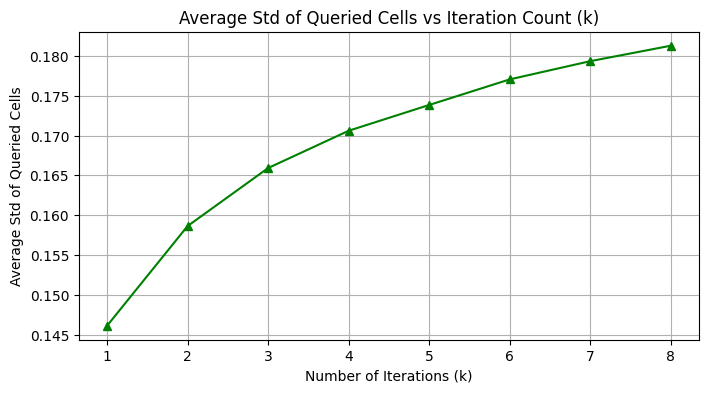

In [70]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

MNAR

In [71]:
generator_mnar = Inject_Missing_Values()
X_missing, index_mnar = generator_mnar.MAR(X,missing_rate=30, dependencies = dependencies_mnar)
mask = X_missing.isna()

results_fullyActive_mnar = []
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 8
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=30, batchsize=64).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mnar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mnar = pd.DataFrame(results_fullyActive_mnar)
print("\nFinal Results:")
print(df_iter_mnar)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2741122672710596
    Avg Std of Queried Cells: 0.1462
    Intermediate MAE after iteration 1: 0.1782
  Final MAE: 0.1782, Time: 29.53s, Unique Queried: 20513, Avg Std: 0.1462

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2629870274483607
    Avg Std of Queried Cells: 0.1597
    Intermediate MAE after iteration 1: 0.1881
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-

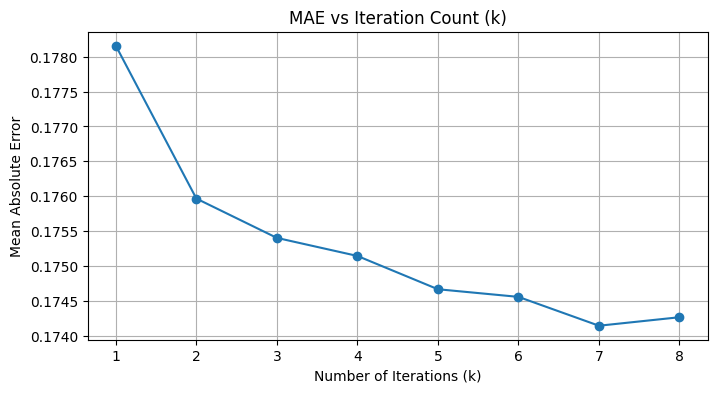

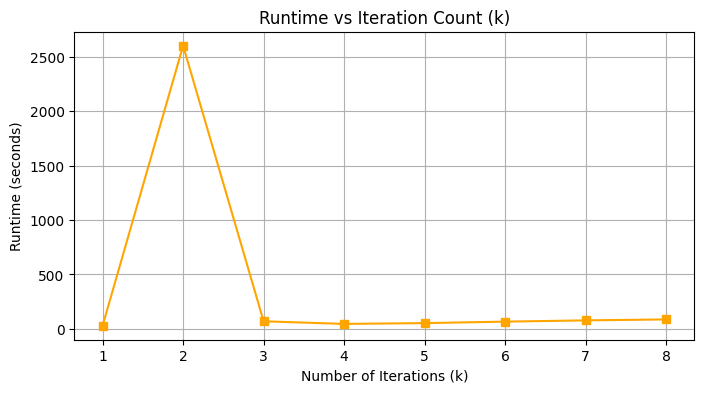

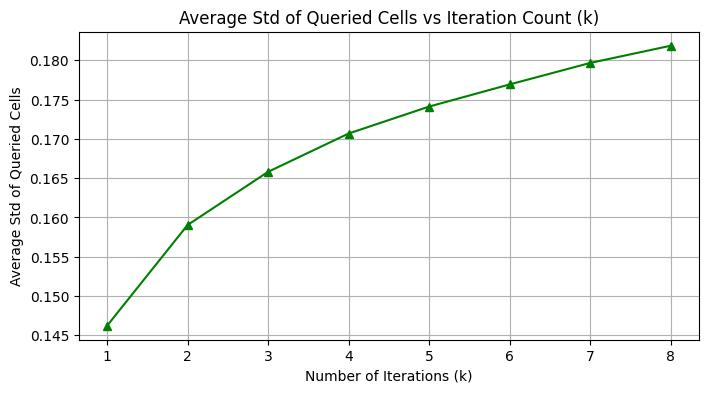

In [72]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

## Visualization

Plotting results...
Saved plot for budget 10%


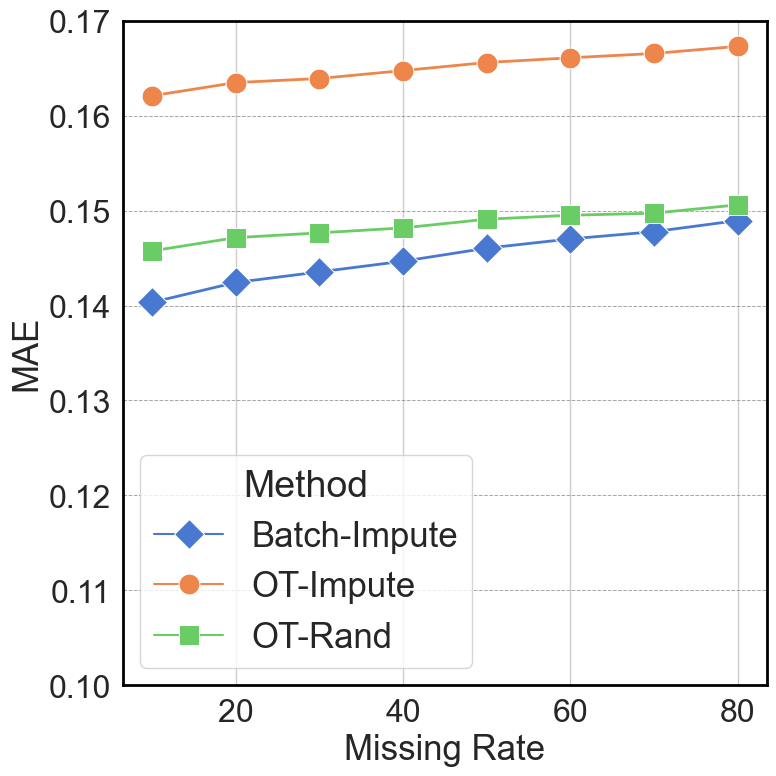

Saved plot for budget 20%


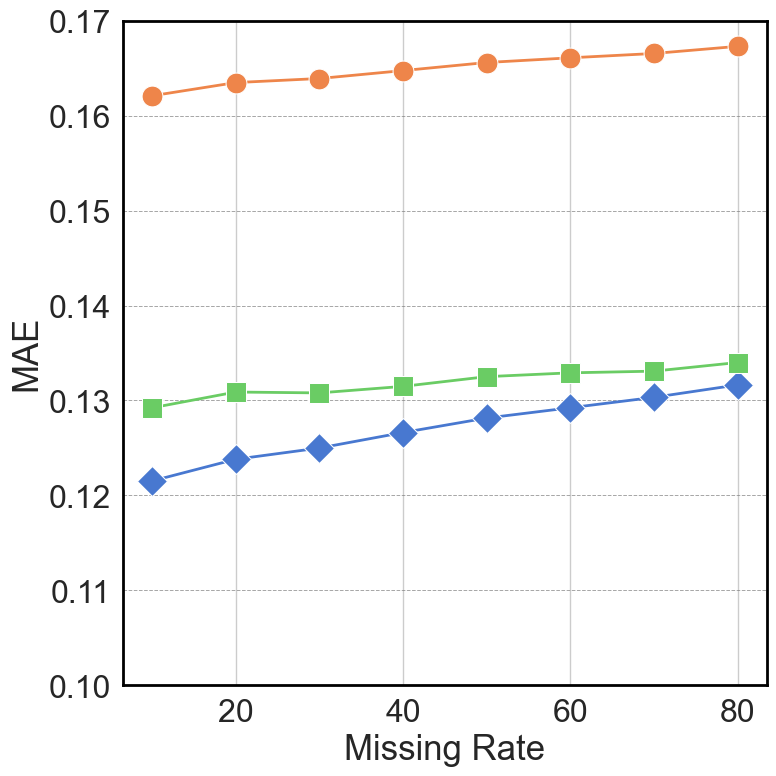

Saved plot for budget 30%


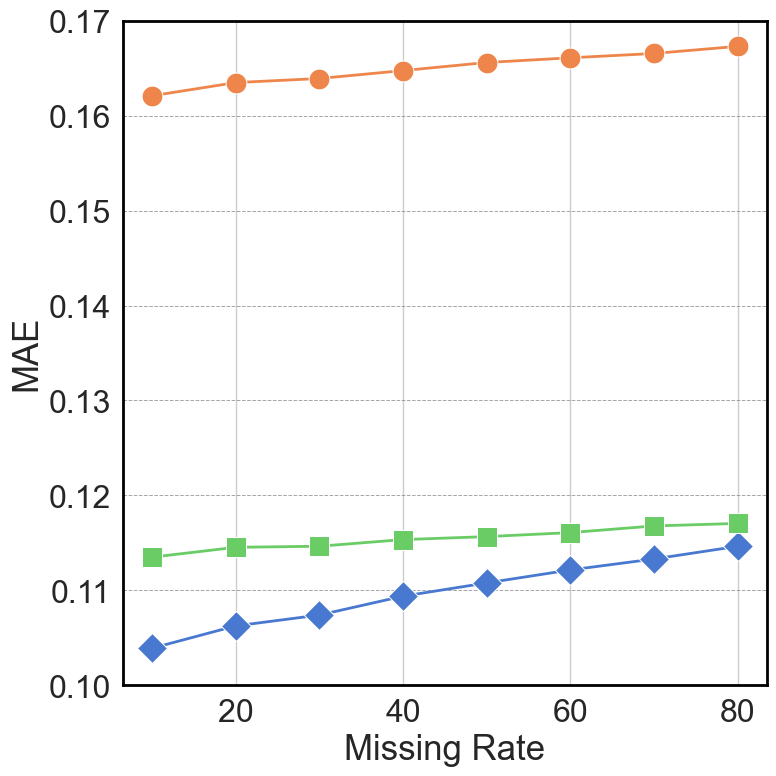

All plots generated successfully.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment results
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_results_mcar_metrics.csv")
df.columns = [ "MissingRate","Budget", "Method", "MAE", "MSE"]

# Plotting
print("Plotting results...")

# Filter to include only the required methods
methods_to_plot = ["OT-Impute", "OT-Rand", "Batch-Impute"]
df = df[df['Method'].isin(methods_to_plot)]
# Replace 'Index' with actual missing rate in percent
df["MissingRate"] = (df["MissingRate"] + 1) * 10


# Rename methods for clarity
#df['Method'] = df['Method'].replace({
    #"OT-Impute": "OT-Impute",
    #"OT + Random": "OT-Rand",
    #"OT + Confidence": "Batch-Impute"
#})

# Set fixed Y-axis range for all plots
y_min = 0.10
y_max = 0.17

# Custom font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Enforce font sizes with rcParams
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Plot settings with the "muted" palette
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")  # Use the muted palette for slightly darker colors

# Define marker styles for each method
markers = {"OT-Impute": "o", "OT-Rand": "s", "Batch-Impute": "D"}  # Circle, square, diamond

for i, budget in enumerate([0.1, 0.2, 0.3]):
    plt.figure(figsize=(8, 8))  # Equal width and height
    subset = df[df['Budget'] == budget]
    
    # Create the line plot
    ax = sns.lineplot(
        data=subset, x="MissingRate", y="MAE", hue="Method", 
        style="Method", markers=markers, dashes=False, markersize=marker_size
    )
    
    # Set consistent Y-axis range
    plt.ylim(y_min, y_max)

    # Customize axis labels
    plt.xlabel("Missing Rate%", fontsize=x_label_fontsize)
    plt.ylabel("MAE", fontsize=y_label_fontsize)

    # Add legend only to the first plot
    if i == 0:
        plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
    else:
        ax.get_legend().remove()

    # Dark black borders on all four sides
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    # Adding small horizontal grid lines for y-axis values
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

    # Adjust the line and marker size
    for line in ax.lines:
        line.set_markersize(marker_size)  # Increased symbol size
        line.set_linewidth(2)

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding small tick marks on the y-axis
    ax.yaxis.set_tick_params(width=1.5, length=5)

    # Save the plot as PDF without title
    plt.tight_layout()
    #plt.savefig(f"active_imputation_budget_{int(budget * 100)}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(
    rf"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MCAR_active_imputation_budget_{int(budget * 100)}.pdf",
    format="pdf",
    bbox_inches="tight"
)
    print(f"Saved plot for budget {int(budget * 100)}%")
    plt.show()
    plt.close()

print("All plots generated successfully.")

Plotting results...
Saved plot for budget 10%


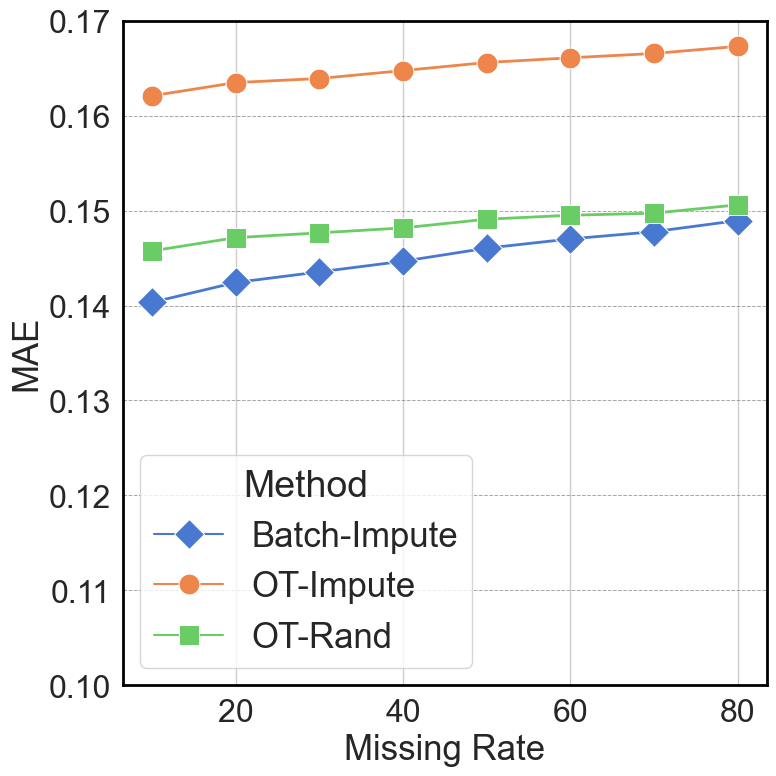

Saved plot for budget 20%


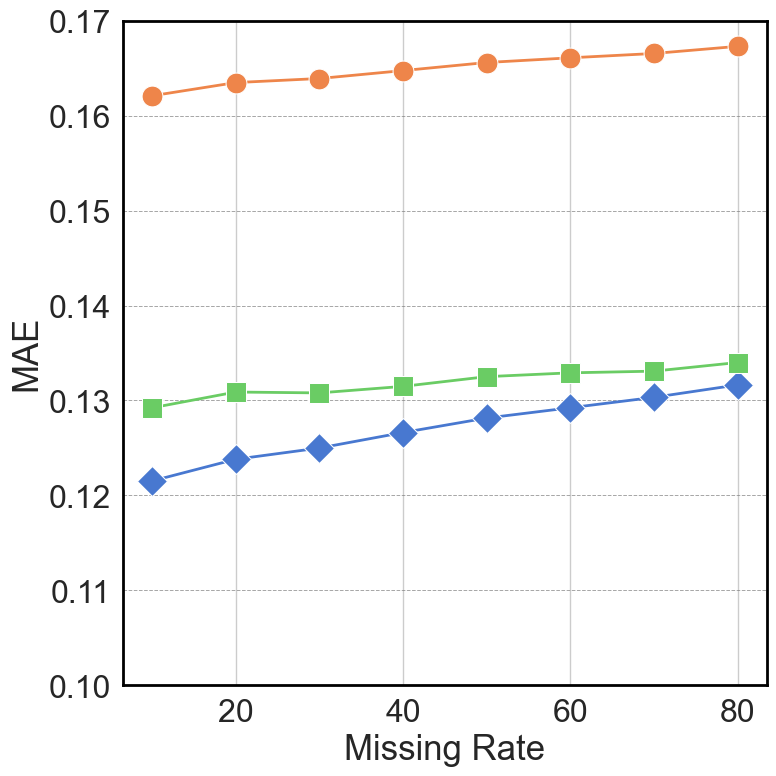

Saved plot for budget 30%


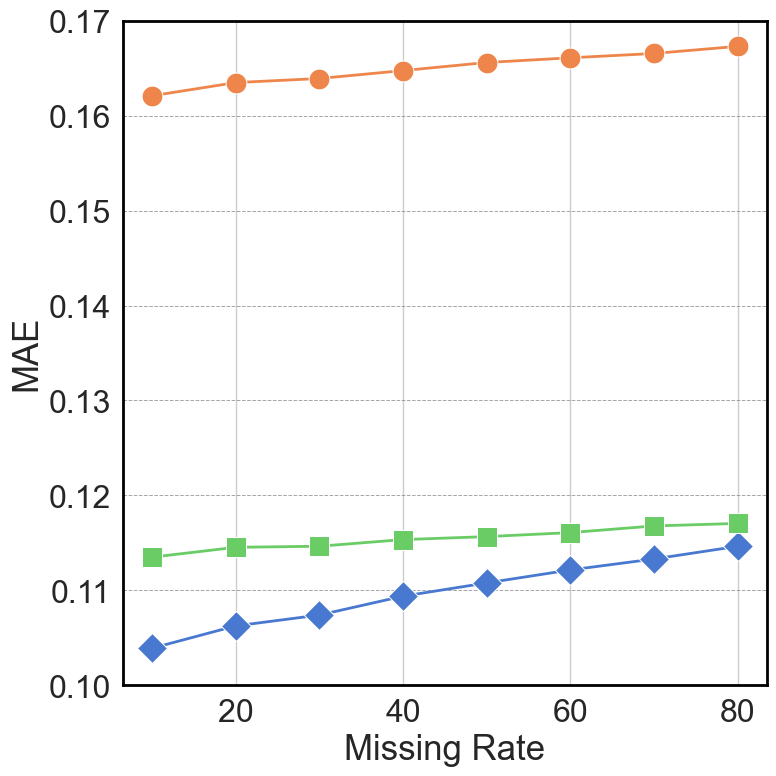

All plots generated successfully.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment results
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_results_mar_metrics.csv")
df.columns = [ "MissingRate","Budget", "Method", "MAE", "MSE"]

# Plotting
print("Plotting results...")

# Filter to include only the required methods
methods_to_plot = ["OT-Impute", "OT-Rand", "Batch-Impute"]
df = df[df['Method'].isin(methods_to_plot)]
# Replace 'Index' with actual missing rate in percent
df["MissingRate"] = (df["MissingRate"] + 1) * 10


# Rename methods for clarity
#df['Method'] = df['Method'].replace({
    #"OT-Impute": "OT-Impute",
    #"OT + Random": "OT-Rand",
    #"OT + Confidence": "Batch-Impute"
#})

# Set fixed Y-axis range for all plots
y_min = 0.10
y_max = 0.17

# Custom font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Enforce font sizes with rcParams
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Plot settings with the "muted" palette
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")  # Use the muted palette for slightly darker colors

# Define marker styles for each method
markers = {"OT-Impute": "o", "OT-Rand": "s", "Batch-Impute": "D"}  # Circle, square, diamond

for i, budget in enumerate([0.1, 0.2, 0.3]):
    plt.figure(figsize=(8, 8))  # Equal width and height
    subset = df[df['Budget'] == budget]
    
    # Create the line plot
    ax = sns.lineplot(
        data=subset, x="MissingRate", y="MAE", hue="Method", 
        style="Method", markers=markers, dashes=False, markersize=marker_size
    )
    
    # Set consistent Y-axis range
    plt.ylim(y_min, y_max)

    # Customize axis labels
    plt.xlabel("Missing Rate", fontsize=x_label_fontsize)
    plt.ylabel("MAE", fontsize=y_label_fontsize)

    # Add legend only to the first plot
    if i == 0:
        plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
    else:
        ax.get_legend().remove()

    # Dark black borders on all four sides
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    # Adding small horizontal grid lines for y-axis values
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

    # Adjust the line and marker size
    for line in ax.lines:
        line.set_markersize(marker_size)  # Increased symbol size
        line.set_linewidth(2)

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding small tick marks on the y-axis
    ax.yaxis.set_tick_params(width=1.5, length=5)

    # Save the plot as PDF without title
    plt.tight_layout()
    #plt.savefig(f"active_imputation_budget_{int(budget * 100)}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(
    rf"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MAR_active_imputation_budget_{int(budget * 100)}.pdf",
    format="pdf",
    bbox_inches="tight"
)
    print(f"Saved plot for budget {int(budget * 100)}%")
    plt.show()
    plt.close()

print("All plots generated successfully.")

Plotting results...
Saved plot for budget 10%


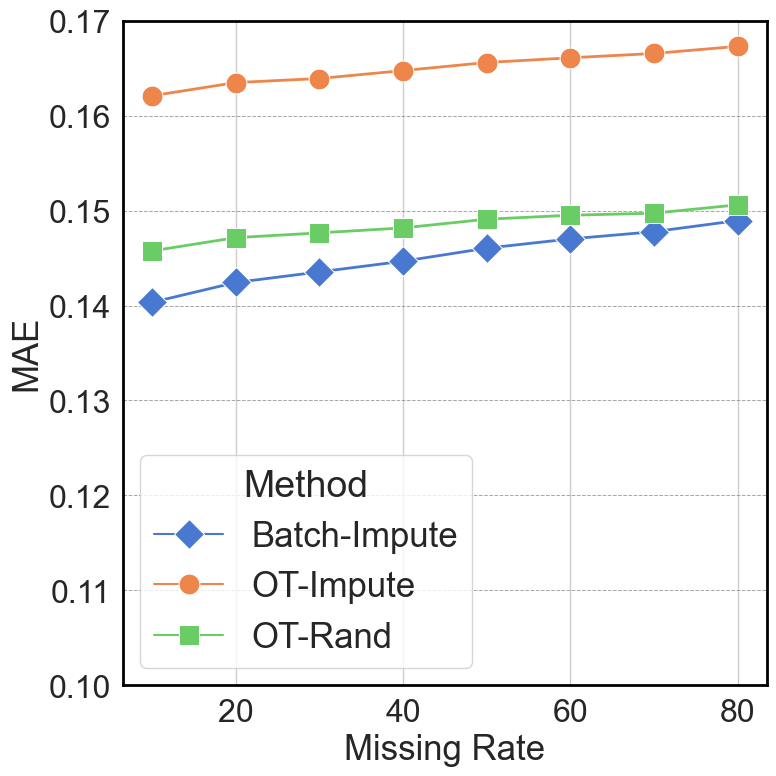

Saved plot for budget 20%


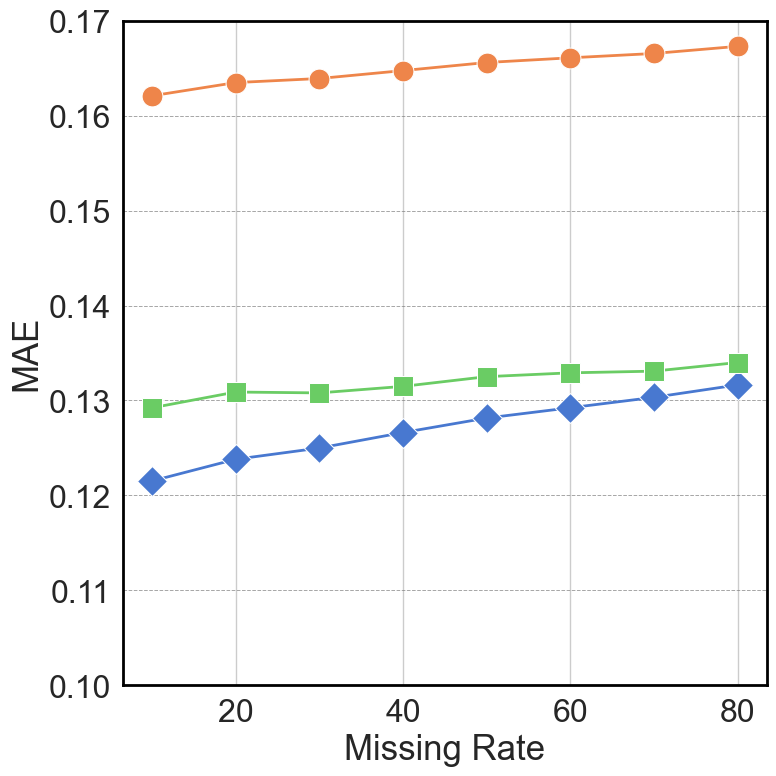

Saved plot for budget 30%


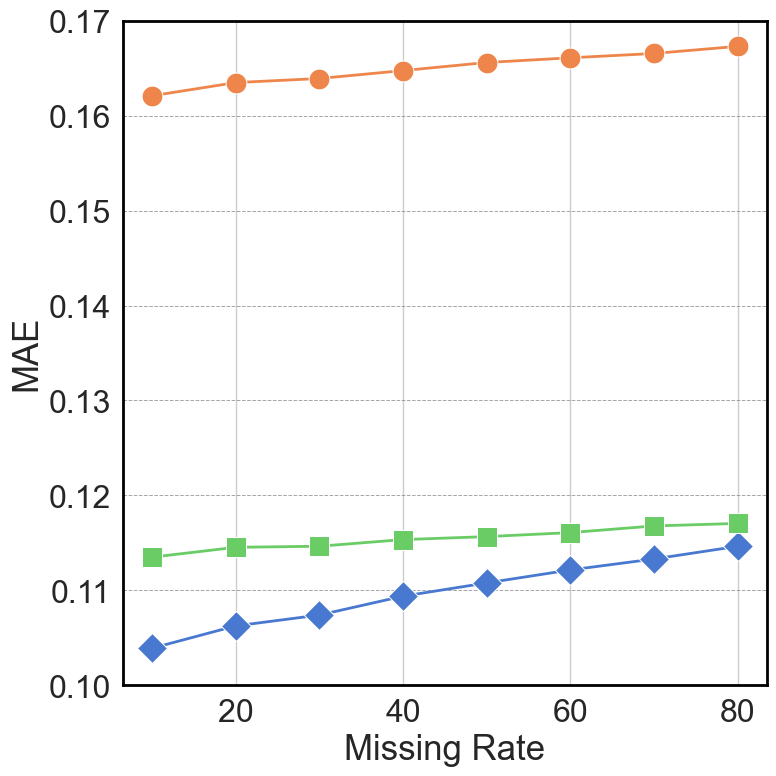

All plots generated successfully.


In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment results
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Adult_results_mnar_metrics.csv")
df.columns = [ "MissingRate","Budget", "Method", "MAE", "MSE"]

# Plotting
print("Plotting results...")

# Filter to include only the required methods
methods_to_plot = ["OT-Impute", "OT-Rand", "Batch-Impute"]
df = df[df['Method'].isin(methods_to_plot)]
# Replace 'Index' with actual missing rate in percent
df["MissingRate"] = (df["MissingRate"] + 1) * 10


# Rename methods for clarity
#df['Method'] = df['Method'].replace({
    #"OT-Impute": "OT-Impute",
    #"OT + Random": "OT-Rand",
    #"OT + Confidence": "Batch-Impute"
#})

# Set fixed Y-axis range for all plots
y_min = 0.10
y_max = 0.17

# Custom font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Enforce font sizes with rcParams
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Plot settings with the "muted" palette
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")  # Use the muted palette for slightly darker colors

# Define marker styles for each method
markers = {"OT-Impute": "o", "OT-Rand": "s", "Batch-Impute": "D"}  # Circle, square, diamond

for i, budget in enumerate([0.1, 0.2, 0.3]):
    plt.figure(figsize=(8, 8))  # Equal width and height
    subset = df[df['Budget'] == budget]
    
    # Create the line plot
    ax = sns.lineplot(
        data=subset, x="MissingRate", y="MAE", hue="Method", 
        style="Method", markers=markers, dashes=False, markersize=marker_size
    )
    
    # Set consistent Y-axis range
    plt.ylim(y_min, y_max)

    # Customize axis labels
    plt.xlabel("Missing Rate", fontsize=x_label_fontsize)
    plt.ylabel("MAE", fontsize=y_label_fontsize)

    # Add legend only to the first plot
    if i == 0:
        plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
    else:
        ax.get_legend().remove()

    # Dark black borders on all four sides
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    # Adding small horizontal grid lines for y-axis values
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

    # Adjust the line and marker size
    for line in ax.lines:
        line.set_markersize(marker_size)  # Increased symbol size
        line.set_linewidth(2)

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding small tick marks on the y-axis
    ax.yaxis.set_tick_params(width=1.5, length=5)

    # Save the plot as PDF without title
    plt.tight_layout()
    #plt.savefig(f"active_imputation_budget_{int(budget * 100)}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(
    rf"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Adult_MNAR_active_imputation_budget_{int(budget * 100)}.pdf",
    format="pdf",
    bbox_inches="tight"
)
    print(f"Saved plot for budget {int(budget * 100)}%")
    plt.show()
    plt.close()

print("All plots generated successfully.")